In [1]:
import pandas as pd
import numpy as np #numpy digunakan untuk perhitungan numerik dan manipulasi array multidimensi.
import matplotlib.pyplot as plt #untuk membuat visualisasi data,
from sklearn.linear_model import LinearRegression #model LinearRegression dari library sklearn
from sklearn.model_selection import train_test_split #membagi dataset menjadi dua subset: 
                            #satu untuk pelatihan (training) dan satu untuk pengujian (testing),
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler #PROCESING DAN FEATURE SCALLING
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold #SCORE
from sklearn.metrics import mean_absolute_percentage_error #MAPE
from sklearn.metrics import mean_absolute_error #MAE
from sklearn.metrics import r2_score #Nilai R² berkisar antara 0 dan 1, 
                            #dengan nilai 1 menunjukkan model yang sempurna.
from sklearn.metrics import mean_squared_error # Semakin rendah nilai MSE, semakin baik modelnya.
import seaborn as sns # tampilan dan desain grafik yang lebih menarik heatmap, boxplot, dan scatterplot
import warnings #mengontrol peringatan dalam Python.
warnings.filterwarnings("ignore") #Mengabaikan semua peringatan yang muncul selama eksekusi program.


In [2]:
df = pd.read_csv('./Data Historis MSFT2014.csv')
df

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,27/12/2024,"430,53","434,60","435,22","426,35","18,12M","-1,73%"
1,26/12/2024,"438,11","439,08","440,94","436,63","8,20M","-0,28%"
2,24/12/2024,"439,33","434,65","439,60","434,19","7,16M","0,94%"
3,23/12/2024,"435,25","436,74","437,65","432,83","19,15M","-0,31%"
4,20/12/2024,"436,60","433,11","443,74","428,63","64,26M","-0,10%"
...,...,...,...,...,...,...,...
2762,08/01/2014,"35,76","36,00","36,14","35,58","59,98M","-1,79%"
2763,07/01/2014,"36,41","36,33","36,49","36,21","35,92M","0,77%"
2764,06/01/2014,"36,13","36,85","36,89","36,11","43,62M","-2,11%"
2765,03/01/2014,"36,91","37,20","37,22","36,60","31,13M","-0,67%"


In [3]:
# Menampilkan beberapa baris pertama dari data
#print(df.head(10) (df.tail(10))

In [4]:
pd.concat([df.head(10), df.tail(10)])

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,27/12/2024,"430,53","434,60","435,22","426,35","18,12M","-1,73%"
1,26/12/2024,"438,11","439,08","440,94","436,63","8,20M","-0,28%"
2,24/12/2024,"439,33","434,65","439,60","434,19","7,16M","0,94%"
3,23/12/2024,"435,25","436,74","437,65","432,83","19,15M","-0,31%"
4,20/12/2024,"436,60","433,11","443,74","428,63","64,26M","-0,10%"
5,19/12/2024,"437,03","441,62","443,18","436,32","22,96M","-0,08%"
6,18/12/2024,"437,39","451,32","452,65","437,02","24,44M","-3,76%"
7,17/12/2024,"454,46","451,01","455,29","449,57","22,73M","0,64%"
8,16/12/2024,"451,59","447,27","452,18","445,28","23,60M","0,97%"
9,13/12/2024,"447,27","448,43","451,43","445,58","20,18M","-0,51%"


In [5]:
#info umum tentang data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Tanggal     2767 non-null   object
 1   Terakhir    2767 non-null   object
 2   Pembukaan   2767 non-null   object
 3   Tertinggi   2767 non-null   object
 4   Terendah    2767 non-null   object
 5   Vol.        2767 non-null   object
 6   Perubahan%  2767 non-null   object
dtypes: object(7)
memory usage: 151.4+ KB


In [6]:
#informasi statistik data
df.describe()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
count,2767,2767,2767,2767,2767,2767,2767
unique,2767,2560,2571,2546,2550,1875,700
top,27/12/2024,"62,30","45,45","47,13","54,00","20,27M","0,00%"
freq,1,4,4,4,4,7,21


In [7]:
#frekuensi kemunculan data
df.value_counts()

Tanggal     Terakhir  Pembukaan  Tertinggi  Terendah  Vol.    Perubahan%
01/02/2016  54,71     54,88      55,09      54,49     44,21M  -0,69%        1
21/04/2021  260,58    258,94     260,68     257,25    24,03M  0,90%         1
21/03/2022  299,16    298,89     300,14     294,90    28,35M  -0,42%        1
21/03/2023  273,78    274,88     275,00     269,52    34,56M  0,57%         1
21/03/2024  429,37    429,83     430,82     427,16    21,30M  0,97%         1
                                                                           ..
11/03/2016  53,07     53,00      53,07      52,38     32,28M  1,96%         1
11/03/2019  112,83    110,99     112,95     110,98    26,49M  2,10%         1
11/03/2020  153,63    157,13     157,70     151,15    56,50M  -4,53%        1
11/03/2021  237,13    234,96     239,17     234,31    29,91M  2,03%         1
31/12/2021  336,32    338,51     339,36     335,85    18,00M  -0,88%        1
Name: count, Length: 2767, dtype: int64

In [8]:
#data dikumpulkan dari tanggal-tanggal
print(df['Tanggal'].nunique())
df['Tanggal'].unique()

2767


array(['27/12/2024', '26/12/2024', '24/12/2024', ..., '06/01/2014',
       '03/01/2014', '02/01/2014'], dtype=object)

In [9]:
# 2. Cek Missing Value
print("=== MISSING VALUE ===")
print("Jumlah missing per kolom:")
print(df.isnull().sum())

print("\nPersentase missing per kolom:")
print((df.isnull().mean() * 100).round(2))

print("\nBaris yang memiliki setidaknya satu missing:")
print(df[df.isnull().any(axis=1)].head(10))  # tampilkan contoh 10 baris

# 3. Cek Duplikat
print("\n=== DUPLIKAT ===")
num_dup = df.duplicated().sum()
print(f"Jumlah baris duplikat (baris yang persis sama): {num_dup}")

if num_dup > 0:
    print("Baris-baris duplikat (contoh):")
    print(df[df.duplicated(keep=False)].head(10))

# 4. Cek Outlier — metode IQR untuk tiap kolom numerik
print("\n=== OUTLIER (IQR) ===")

def detect_outliers_iqr(dataframe, kolom):
    Q1 = dataframe[kolom].quantile(0.25)
    Q3 = dataframe[kolom].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    out = dataframe[(dataframe[kolom] < lower) | (dataframe[kolom] > upper)]
    return out

# pilih kolom numerik untuk dicek
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()
print("Kolom numerik yang dicek:", kolom_numerik)

for kol in kolom_numerik:
    out_kol = detect_outliers_iqr(df, kol)
    print(f"\nKolom: {kol}")
    print(f"Jumlah outlier di kolom {kol}: {len(out_kol)}")
    print("Contoh outlier:")
    print(out_kol.head(5))

# 5. Visualisasi Outlier (opsional)
# Misalnya untuk satu kolom
if len(kolom_numerik) > 0:
    kol0 = kolom_numerik[0]
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[kol0])
    plt.title(f"Boxplot kolom {kol0}")
    plt.show()

    # Histogram
    plt.figure(figsize=(8,4))
    sns.histplot(df[kol0], bins=30, kde=True)
    plt.title(f"Histogram kolom {kol0}")
    plt.show()

=== MISSING VALUE ===
Jumlah missing per kolom:
Tanggal       0
Terakhir      0
Pembukaan     0
Tertinggi     0
Terendah      0
Vol.          0
Perubahan%    0
dtype: int64

Persentase missing per kolom:
Tanggal       0.0
Terakhir      0.0
Pembukaan     0.0
Tertinggi     0.0
Terendah      0.0
Vol.          0.0
Perubahan%    0.0
dtype: float64

Baris yang memiliki setidaknya satu missing:
Empty DataFrame
Columns: [Tanggal, Terakhir, Pembukaan, Tertinggi, Terendah, Vol., Perubahan%]
Index: []

=== DUPLIKAT ===
Jumlah baris duplikat (baris yang persis sama): 0

=== OUTLIER (IQR) ===
Kolom numerik yang dicek: []


In [10]:
# Menggantikan nilainya dengan nilai mode (jika ada jumlah selain 0)
#df["Vol."]=df["Vol."].fillna(df["Vol."].mode()[0])
#df.info()
#cek data duplikat
#df.duplicated().sum()

In [11]:
#casting/konversi tipe data

In [12]:
# Mengubah tipe data kolom tangal menjadi datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')

# Mengubah tipe data kolom harga menjadi float
columns_harga = ['Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah']
df[columns_harga] = df[columns_harga].replace(',', '', regex=True).astype(float)

#Ubah tipe data kolom Vol. menjadi tipe data numerik:
df['Vol.'] = df['Vol.'].astype(str).str.replace(',', '')
df['Vol.'] = df['Vol.'].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)

#Ubah tipe data kolom Change % menjadi tipe data numerik:
#df['Perubahan%'] = df['Perubahan%'].str.replace('').astype(float)

# Langkah 1: Ganti nilai kosong (NaN) menjadi string kosong untuk menghindari error .str
df['Perubahan%'] = df['Perubahan%'].astype(str).str.replace('%', '', 
                                                            regex=True).str.replace(',', '.')

#Jika Anda ingin hasil akhir berupa angka, ubah tipe data menjadi float:
df['Perubahan%'] = pd.to_numeric(df['Perubahan%'], errors='coerce')


#Langkah 2: Bersihkan simbol % dan ganti koma dengan titik
#df['Perubahan%'] = df['Perubahan%'].str.replace('%', '', regex=True).str.replace(',', '.')

#Langkah 3: Ubah tipe data menjadi float, tangani kesalahan dengan errors='coerce'
#df['Perubahan%'] = pd.to_numeric(df['Perubahan%'], errors='coerce')


In [13]:
df.dtypes

Tanggal       datetime64[ns]
Terakhir             float64
Pembukaan            float64
Tertinggi            float64
Terendah             float64
Vol.                 float64
Perubahan%           float64
dtype: object

In [14]:
#mengecek hasil perubahan dari data seelumnya 
df

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,2024-12-27,43053.0,43460.0,43522.0,42635.0,1812.0,-1.73
1,2024-12-26,43811.0,43908.0,44094.0,43663.0,820.0,-0.28
2,2024-12-24,43933.0,43465.0,43960.0,43419.0,716.0,0.94
3,2024-12-23,43525.0,43674.0,43765.0,43283.0,1915.0,-0.31
4,2024-12-20,43660.0,43311.0,44374.0,42863.0,6426.0,-0.10
...,...,...,...,...,...,...,...
2762,2014-01-08,3576.0,3600.0,3614.0,3558.0,5998.0,-1.79
2763,2014-01-07,3641.0,3633.0,3649.0,3621.0,3592.0,0.77
2764,2014-01-06,3613.0,3685.0,3689.0,3611.0,4362.0,-2.11
2765,2014-01-03,3691.0,3720.0,3722.0,3660.0,3113.0,-0.67


In [15]:
df.describe().round(2)

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
count,2767,2767.00,2767.00,2767.00,2767.00,2767.00,2767.00
mean,2019-06-30 02:14:47.314781440,17425.43,17420.96,17586.19,17248.04,2931.38,0.10
min,2014-01-02 00:00:00,3498.00,3473.00,3588.00,3463.00,716.00,-14.74
25%,2016-09-28 12:00:00,5785.50,5786.00,5806.00,5742.00,2088.50,-0.68
50%,2019-07-01 00:00:00,13469.00,13488.00,13576.00,13351.00,2625.00,0.08
75%,2022-03-28 12:00:00,27136.00,27119.00,27439.00,26792.50,3357.00,0.96
max,2024-12-27 00:00:00,46756.00,46700.00,46835.00,46446.00,20253.00,14.22
std,NaN,12425.78,12425.07,12535.40,12305.31,1372.41,1.67


In [16]:
perubahan = df['Perubahan%'].isnull().sum()
print("Jumlah missing value di kolom Tanggal:", perubahan)


Jumlah missing value di kolom Tanggal: 0


In [17]:
missing_rows = df[df['Tanggal'].isnull()]
print("Baris dengan nilai kosong pada kolom Tanggal:\n", missing_rows)

Baris dengan nilai kosong pada kolom Tanggal:
 Empty DataFrame
Columns: [Tanggal, Terakhir, Pembukaan, Tertinggi, Terendah, Vol., Perubahan%]
Index: []


In [18]:
# Alasan std Kolom Tanggal Adalah NaN
# Kolom Tanggal bertipe datetime, sehingga tidak mendukung operasi numerik 
# seperti penghitungan standar deviasi secara langsung.

# std pada datetime akan selalu NaN, meskipun tidak ada missing value.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     2767 non-null   datetime64[ns]
 1   Terakhir    2767 non-null   float64       
 2   Pembukaan   2767 non-null   float64       
 3   Tertinggi   2767 non-null   float64       
 4   Terendah    2767 non-null   float64       
 5   Vol.        2767 non-null   float64       
 6   Perubahan%  2767 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 151.4 KB


In [20]:
# Hitung rata-rata waktu
#mean_tanggal = df['Tanggal'].mean()

# Hitung selisih dari rata-rata
#df['Delta_hari'] = (df['Tanggal'] - mean_tanggal).dt.total_seconds() / (24 * 3600)

# Hitung standar deviasi selisih waktu
#std_tanggal_hari = df['Delta_hari'].std()
#print("Standar deviasi (hari):", std_tanggal_hari)
#df

In [21]:
##>>>VISUALISASI DATA<<<<

Tanggal       0.951266
Terakhir      1.000000
Pembukaan     0.999752
Tertinggi     0.999878
Terendah      0.999895
Vol.         -0.192663
Perubahan%    0.006252
Name: Terakhir, dtype: float64


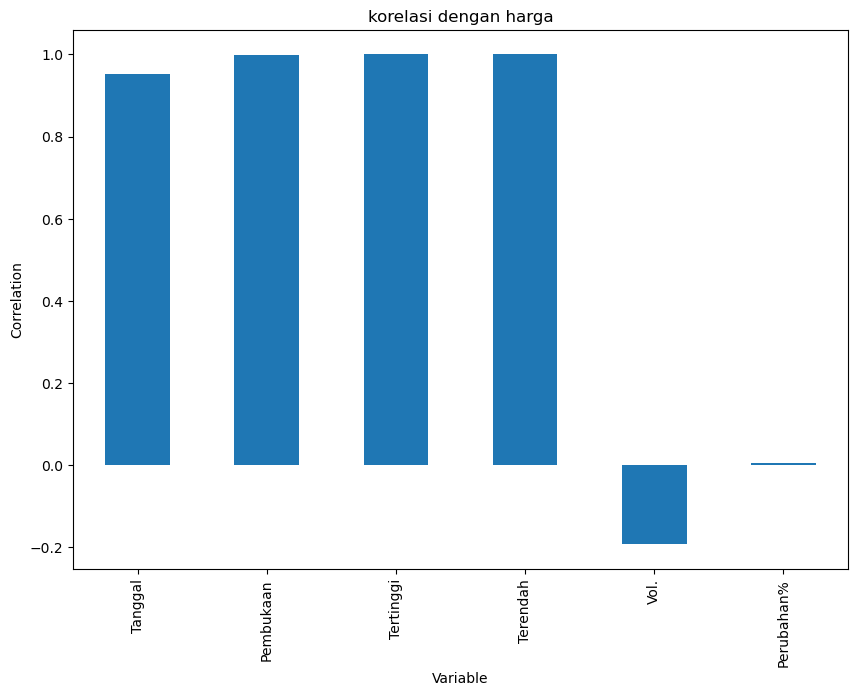

In [22]:
# Menghitung korelasi antara kolom Price dengan kolom lain
correlation = df.corr()['Terakhir']
print(correlation)
# Plot korelasi
plt.figure(figsize=(10, 7))
correlation.drop('Terakhir').plot(kind='bar')
plt.xlabel('Variable')
plt.ylabel('Correlation')
plt.title('korelasi dengan harga')
plt.savefig('foto./korelasi-dengan-hargasaham.png')
plt.show()


In [23]:
#Distribusi Data Time series Harga Penutupan

In [24]:
#membagi waktu menjadi har,minggu,bulan,tahun


df['day'] =df['Tanggal'].dt.day
df['week'] = df['Tanggal'].dt.isocalendar().week #versi terbaru pandas 1.1.0++ dt.isocalendar
df['month'] =df['Tanggal'].dt.month
df['year'] =df['Tanggal'].dt.year

# Menghitung Penurunan Harga
df['Perubahan Terakhir'] = df['Pembukaan'].diff()
###################
#df.dropna(subset=['Perubahan Terakhir'], inplace=True)


df

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,day,week,month,year,Perubahan Terakhir
0,2024-12-27,43053.0,43460.0,43522.0,42635.0,1812.0,-1.73,27,52,12,2024,NaN
1,2024-12-26,43811.0,43908.0,44094.0,43663.0,820.0,-0.28,26,52,12,2024,448.0
2,2024-12-24,43933.0,43465.0,43960.0,43419.0,716.0,0.94,24,52,12,2024,-443.0
3,2024-12-23,43525.0,43674.0,43765.0,43283.0,1915.0,-0.31,23,52,12,2024,209.0
4,2024-12-20,43660.0,43311.0,44374.0,42863.0,6426.0,-0.10,20,51,12,2024,-363.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2762,2014-01-08,3576.0,3600.0,3614.0,3558.0,5998.0,-1.79,8,2,1,2014,12.0
2763,2014-01-07,3641.0,3633.0,3649.0,3621.0,3592.0,0.77,7,2,1,2014,33.0
2764,2014-01-06,3613.0,3685.0,3689.0,3611.0,4362.0,-2.11,6,2,1,2014,52.0
2765,2014-01-03,3691.0,3720.0,3722.0,3660.0,3113.0,-0.67,3,1,1,2014,35.0


In [25]:
#cek mising
df.isna().sum()

Tanggal               0
Terakhir              0
Pembukaan             0
Tertinggi             0
Terendah              0
Vol.                  0
Perubahan%            0
day                   0
week                  0
month                 0
year                  0
Perubahan Terakhir    1
dtype: int64

In [26]:
# Menggantikan nilainya dengan nilai mode (jika ada jumlah selain 0)
df["Perubahan Terakhir"]=df["Perubahan Terakhir"].fillna(df["Perubahan Terakhir"].mode()[0])
#df.info()
#cek data duplikat
df.duplicated().sum()
df.isna().sum()

Tanggal               0
Terakhir              0
Pembukaan             0
Tertinggi             0
Terendah              0
Vol.                  0
Perubahan%            0
day                   0
week                  0
month                 0
year                  0
Perubahan Terakhir    0
dtype: int64

Tanggal               0.951266
Terakhir              1.000000
Pembukaan             0.999752
Tertinggi             0.999878
Terendah              0.999895
Vol.                 -0.192663
Perubahan%            0.006252
day                   0.000775
week                  0.082971
month                 0.083241
year                  0.947389
Perubahan Terakhir   -0.024899
Name: Terakhir, dtype: float64


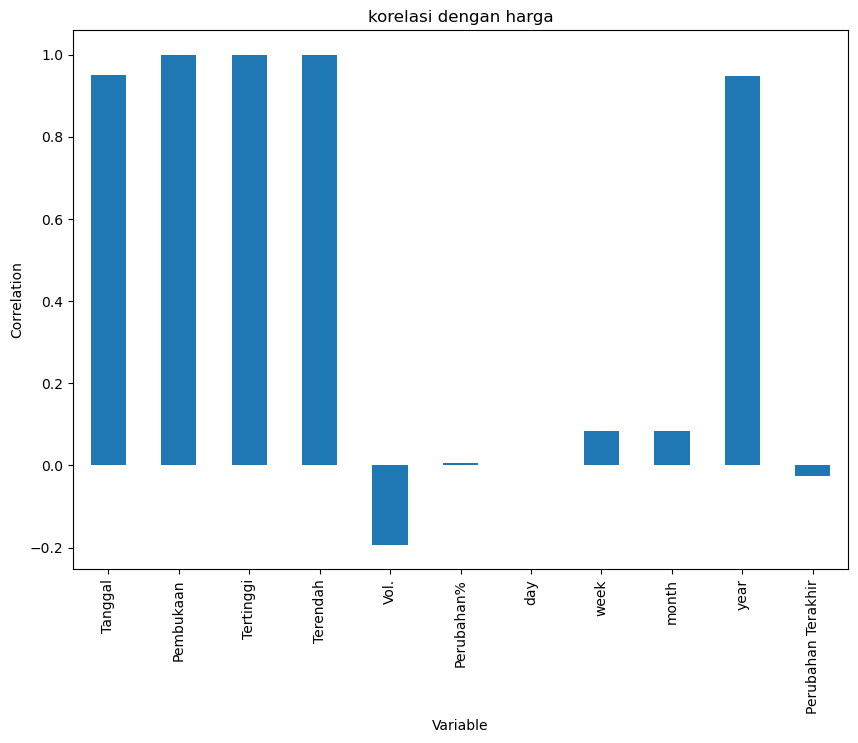

In [27]:
# Menghitung korelasi antara kolom Price dengan kolom lain
correlation = df.corr()['Terakhir']
print(correlation)
# Plot korelasi
plt.figure(figsize=(10, 7))
correlation.drop('Terakhir').plot(kind='bar')
plt.xlabel('Variable')
plt.ylabel('Correlation')
plt.title('korelasi dengan harga')
plt.savefig('foto./korelasi-dengan-hargasaham1.png')
plt.show()


In [28]:
df.describe().round(2)

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,day,week,month,year,Perubahan Terakhir
count,2767,2767.00,2767.00,2767.00,2767.00,2767.00,2767.00,2767.00,2767.0,2767.00,2767.00,2767.00
mean,2019-06-30 02:14:47.314781440,17425.43,17420.96,17586.19,17248.04,2931.38,0.10,15.73,26.66,6.54,2018.99,-14.35
min,2014-01-02 00:00:00,3498.00,3473.00,3588.00,3463.00,716.00,-14.74,1.00,1.0,1.00,2014.00,-2263.00
25%,2016-09-28 12:00:00,5785.50,5786.00,5806.00,5742.00,2088.50,-0.68,8.00,14.0,4.00,2016.00,-113.00
50%,2019-07-01 00:00:00,13469.00,13488.00,13576.00,13351.00,2625.00,0.08,16.00,27.0,7.00,2019.00,-10.00
75%,2022-03-28 12:00:00,27136.00,27119.00,27439.00,26792.50,3357.00,0.96,23.00,40.0,10.00,2022.00,78.00
max,2024-12-27 00:00:00,46756.00,46700.00,46835.00,46446.00,20253.00,14.22,31.00,53.0,12.00,2024.00,2332.00
std,NaN,12425.78,12425.07,12535.40,12305.31,1372.41,1.67,8.75,14.95,3.43,3.16,339.59


In [29]:
import matplotlib.pyplot as plt

# Tampilkan tabel ringkasan
import pandas as pd
summary = pd.DataFrame({
    "Jumlah Baris": df.notnull().sum(),
    "Nilai Minimal": df.min(),
    "Nilai Maksimal": df.max(),
    "Jumlah Unik": df.nunique()
})

# Simpan ke Excel / CSV
summary.to_excel("ringkasan_dataset.xlsx", index=True)
summary.to_csv("ringkasan_dataset.csv", index=True)

# Tampilkan
summary


,Jumlah Baris,Nilai Minimal,Nilai Maksimal,Jumlah Unik
Tanggal,2767,2014-01-02 00:00:00,2024-12-27 00:00:00,2767
Terakhir,2767,3498.0,46756.0,2560
Pembukaan,2767,3473.0,46700.0,2571
Tertinggi,2767,3588.0,46835.0,2546
Terendah,2767,3463.0,46446.0,2550
Vol.,2767,716.0,20253.0,1875
Perubahan%,2767,-14.74,14.22,700
day,2767,1,31,31
week,2767,1,53,53
month,2767,1,12,12


In [30]:
#melihat colum dan Dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Tanggal             2767 non-null   datetime64[ns]
 1   Terakhir            2767 non-null   float64       
 2   Pembukaan           2767 non-null   float64       
 3   Tertinggi           2767 non-null   float64       
 4   Terendah            2767 non-null   float64       
 5   Vol.                2767 non-null   float64       
 6   Perubahan%          2767 non-null   float64       
 7   day                 2767 non-null   int32         
 8   week                2767 non-null   UInt32        
 9   month               2767 non-null   int32         
 10  year                2767 non-null   int32         
 11  Perubahan Terakhir  2767 non-null   float64       
dtypes: UInt32(1), datetime64[ns](1), float64(7), int32(3)
memory usage: 219.0 KB


In [31]:
#menyimpan dataset yang telah dibersihkan
df.to_csv('./dataset/CleandataTrainMSFT.csv', index=False)

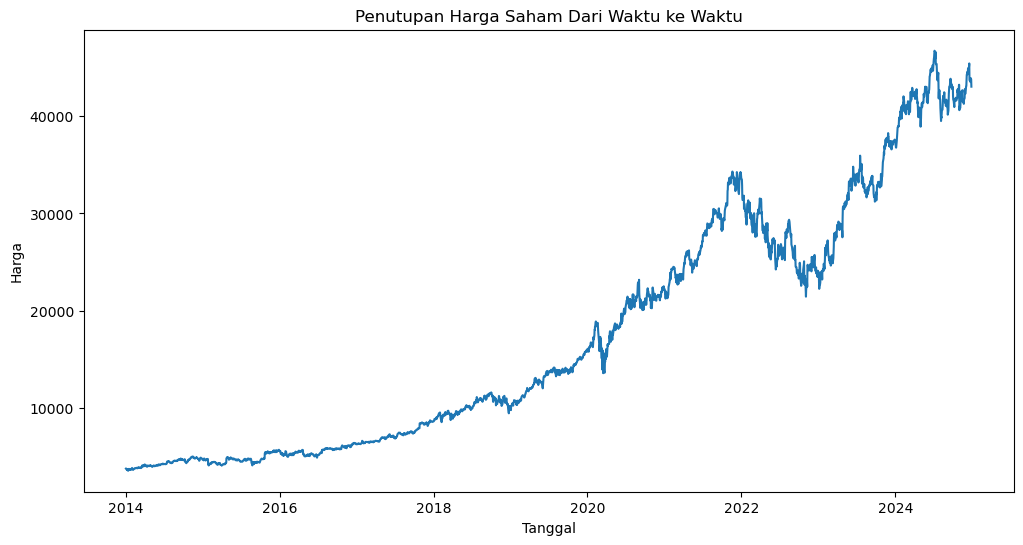

In [32]:
# Plot harga saham seiring waktu
plt.figure(figsize=(12, 6))
plt.plot(df['Tanggal'], df['Terakhir'])
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.title('Penutupan Harga Saham Dari Waktu ke Waktu')
plt.savefig('foto./Penutupa-Harga-Saham-Dari-Waktu-keWaktu.png')
plt.show()

In [33]:
df.groupby('year')['Terakhir'].agg([len,min,max])

,len,min,max
year,,,
2014,252,3498.0,4961.0
2015,252,4029.0,5655.0
2016,253,4843.0,6362.0
2017,251,6230.0,8685.0
2018,251,8501.0,11561.0
2019,252,9740.0,15896.0
2020,253,13542.0,23165.0
2021,252,21225.0,34311.0
2022,251,21425.0,33475.0


In [34]:
#data yang di ambil awal tahun 2021- akhir tahun 2024

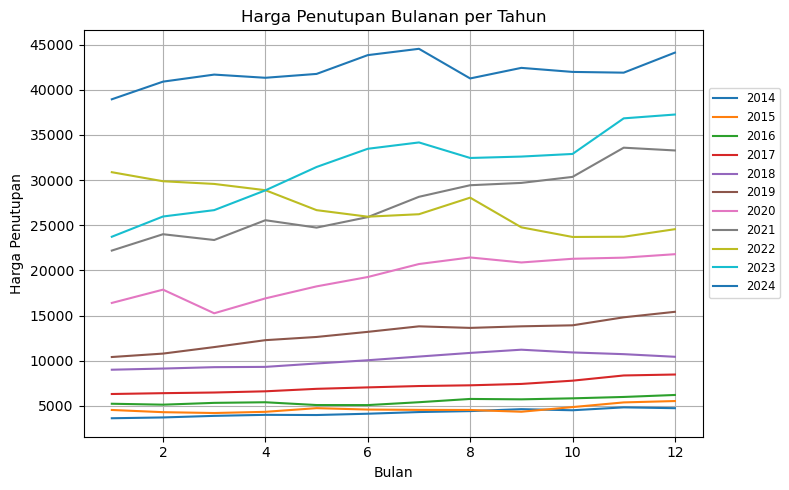

In [35]:
# pivot table sudah dibuat seperti ini:
monthly_sales = pd.pivot_table(df, values="Terakhir", columns="year", index="month")

fig, ax = plt.subplots(figsize=(8, 5))

for year in monthly_sales.columns:
    ax.plot(monthly_sales.index, monthly_sales[year], label=str(year))

# Menempatkan legenda di luar plot agar lebih rapi
ax.legend(loc='center left', bbox_to_anchor=(1,0.6), ncol=1, fontsize='small')

ax.set_xlabel('Bulan')
ax.set_ylabel('Harga Penutupan')
ax.set_title('Harga Penutupan Bulanan per Tahun')
ax.grid(True)
plt.tight_layout()
plt.savefig('foto./Penutupan-Bulanan-perTahun.png')
plt.show()

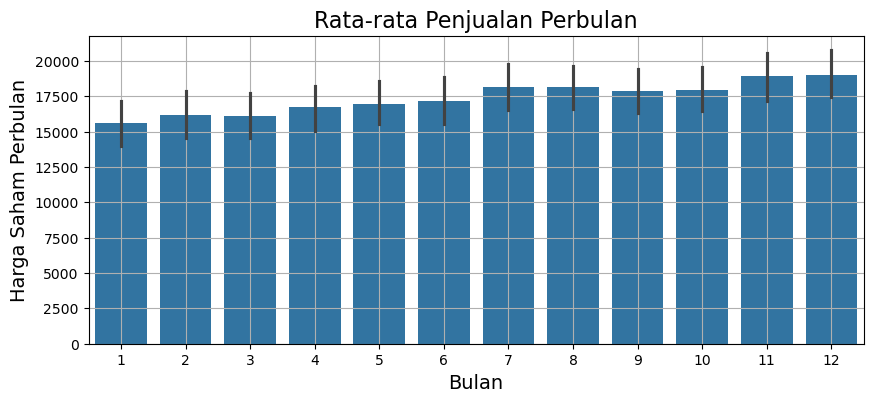

In [36]:
#visualisasi data penjualan, untuk mengetahui bulan dengan tingkat penjualan tertinggi
plt.figure(figsize=(10,4))
sns.barplot(x='month',y='Terakhir',data=df)
plt.ylabel('Harga Saham Perbulan',fontsize=14)
plt.xlabel('Bulan',fontsize=14)
plt.title('Rata-rata Penjualan Perbulan',fontsize=16)
plt.savefig('foto./rata2-penjualan-perbulan.png')
plt.grid()


In [37]:
df

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,day,week,month,year,Perubahan Terakhir
0,2024-12-27,43053.0,43460.0,43522.0,42635.0,1812.0,-1.73,27,52,12,2024,12.0
1,2024-12-26,43811.0,43908.0,44094.0,43663.0,820.0,-0.28,26,52,12,2024,448.0
2,2024-12-24,43933.0,43465.0,43960.0,43419.0,716.0,0.94,24,52,12,2024,-443.0
3,2024-12-23,43525.0,43674.0,43765.0,43283.0,1915.0,-0.31,23,52,12,2024,209.0
4,2024-12-20,43660.0,43311.0,44374.0,42863.0,6426.0,-0.10,20,51,12,2024,-363.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2762,2014-01-08,3576.0,3600.0,3614.0,3558.0,5998.0,-1.79,8,2,1,2014,12.0
2763,2014-01-07,3641.0,3633.0,3649.0,3621.0,3592.0,0.77,7,2,1,2014,33.0
2764,2014-01-06,3613.0,3685.0,3689.0,3611.0,4362.0,-2.11,6,2,1,2014,52.0
2765,2014-01-03,3691.0,3720.0,3722.0,3660.0,3113.0,-0.67,3,1,1,2014,35.0


In [38]:
df.groupby('month')['Terakhir'].agg([len,min,max,sum])

,len,min,max,sum
month,,,,
1,223,3498.0,40972.0,3477194.0
2,212,3582.0,42055.0,3435671.0
3,241,3770.0,42937.0,3878386.0
4,227,3918.0,42793.0,3795340.0
5,233,3906.0,43052.0,3958979.0
6,233,4029.0,45285.0,4004677.0
7,232,4167.0,46756.0,4205498.0
8,244,4047.0,42480.0,4435562.0
9,225,4182.0,43869.0,4030097.0


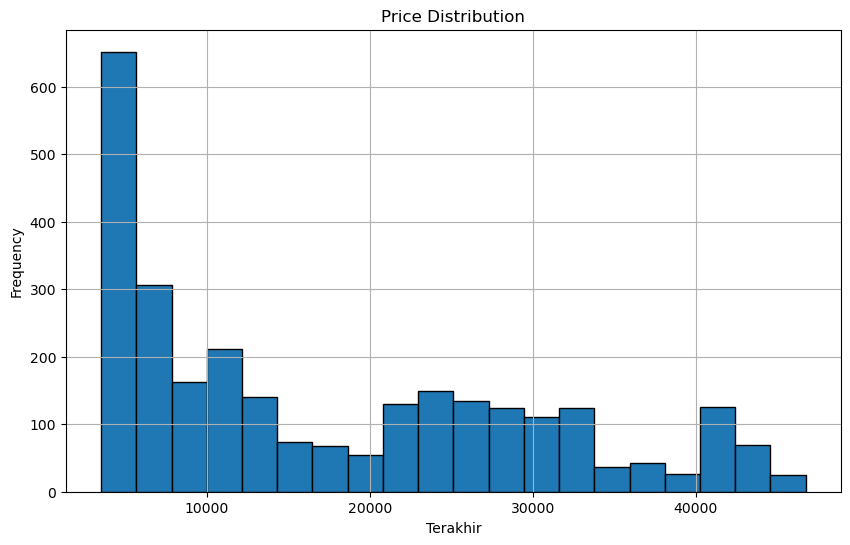

In [39]:
# Histogram harga saham
plt.figure(figsize=(10, 6))
plt.hist(df['Terakhir'], bins=20, edgecolor='k')
plt.xlabel('Terakhir')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.savefig('foto./distribusiPrice.png')
plt.grid()
plt.show()

<Figure size 1600x600 with 0 Axes>

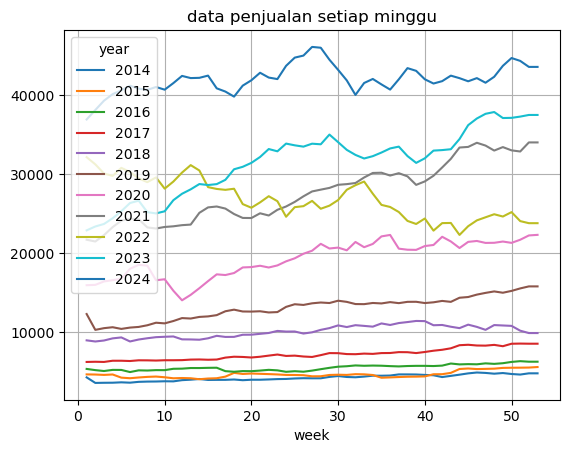

In [40]:
#Visualisasi data penjualan setiap minggu
plt.figure(figsize=(16,6))
Price = pd.pivot_table(df, values = "Terakhir", columns = "year", index = "week").interpolate()
Price.plot()
plt.title('data penjualan setiap minggu')
plt.savefig('foto./data-penjualan-setiap-mingguu.png')
plt.grid()

In [41]:
print(df['day'].interpolate().count())

2767


In [42]:
df

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,day,week,month,year,Perubahan Terakhir
0,2024-12-27,43053.0,43460.0,43522.0,42635.0,1812.0,-1.73,27,52,12,2024,12.0
1,2024-12-26,43811.0,43908.0,44094.0,43663.0,820.0,-0.28,26,52,12,2024,448.0
2,2024-12-24,43933.0,43465.0,43960.0,43419.0,716.0,0.94,24,52,12,2024,-443.0
3,2024-12-23,43525.0,43674.0,43765.0,43283.0,1915.0,-0.31,23,52,12,2024,209.0
4,2024-12-20,43660.0,43311.0,44374.0,42863.0,6426.0,-0.10,20,51,12,2024,-363.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2762,2014-01-08,3576.0,3600.0,3614.0,3558.0,5998.0,-1.79,8,2,1,2014,12.0
2763,2014-01-07,3641.0,3633.0,3649.0,3621.0,3592.0,0.77,7,2,1,2014,33.0
2764,2014-01-06,3613.0,3685.0,3689.0,3611.0,4362.0,-2.11,6,2,1,2014,52.0
2765,2014-01-03,3691.0,3720.0,3722.0,3660.0,3113.0,-0.67,3,1,1,2014,35.0


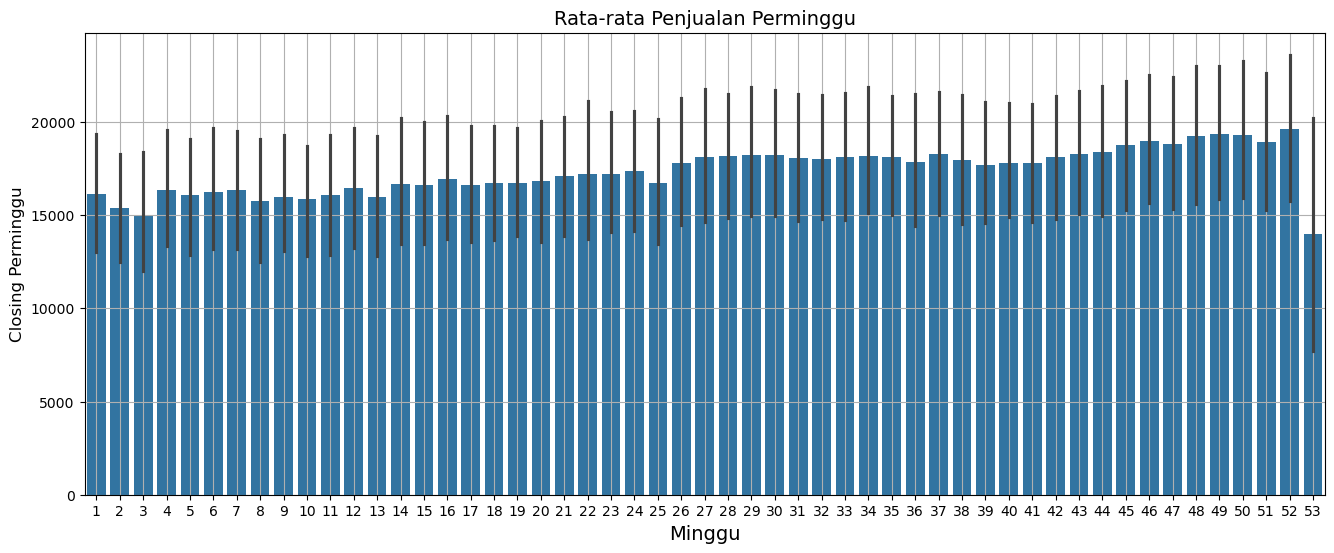

In [43]:
plt.figure(figsize=(16,6))
sns.barplot(x='week',y='Terakhir',data=df)
plt.ylabel('Closing Perminggu',fontsize=12)
plt.xlabel('Minggu',fontsize=14)
plt.title('Rata-rata Penjualan Perminggu',fontsize=14)
plt.savefig('foto./penjualan-minggu.png')
plt.grid()

In [44]:
df.groupby('week')['Terakhir'].mean().sort_values(ascending=False).head()

week
52    19608.133333
49    19331.203704
50    19317.327273
48    19234.000000
46    18993.036364
Name: Terakhir, dtype: float64

In [45]:
#Open (Harga Pembukaan)

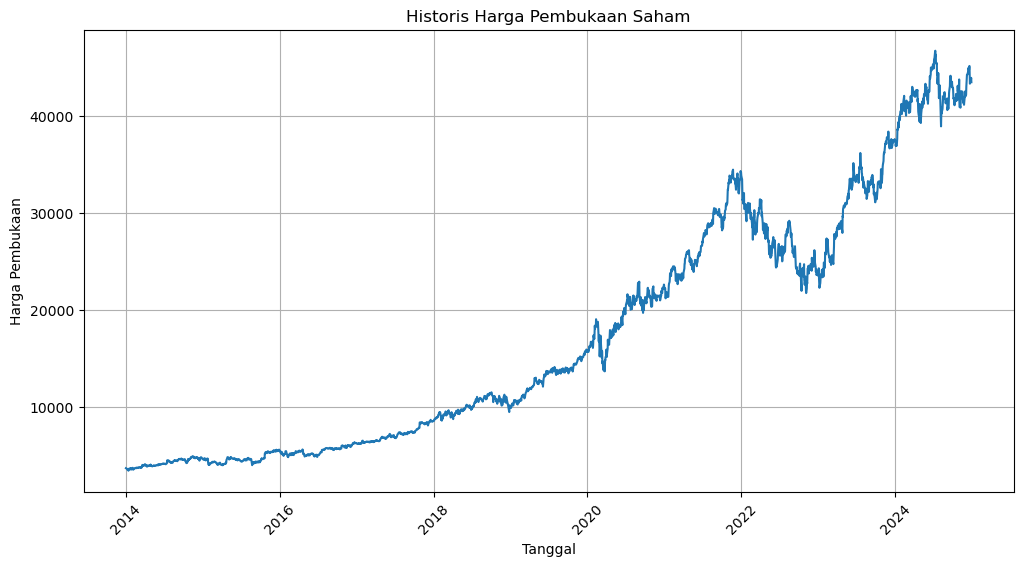

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(df['Tanggal'], df['Pembukaan'])
plt.title('Historis Harga Pembukaan Saham')
plt.xlabel('Tanggal')
plt.ylabel('Harga Pembukaan')
plt.xticks(rotation=45)
plt.savefig('foto./Historis-Harga-Pembukaan-Saham.png')
plt.grid()
plt.show()

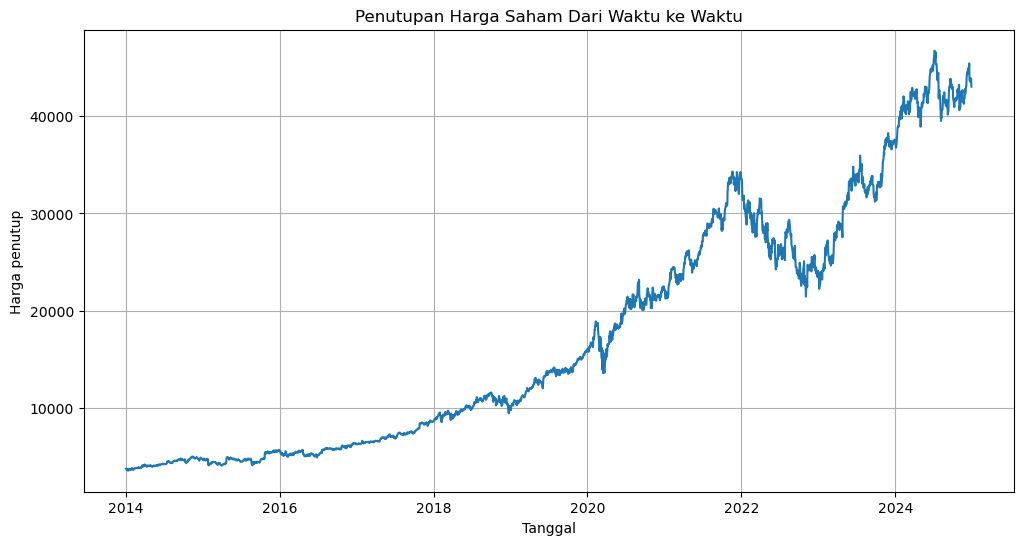

In [47]:
# Plot harga saham seiring waktu
plt.figure(figsize=(12, 6))
plt.plot(df['Tanggal'], df['Terakhir'])
plt.xlabel('Tanggal')
plt.ylabel('Harga penutup')
plt.title('Penutupan Harga Saham Dari Waktu ke Waktu')
plt.savefig('foto./Harga-Saham-Dari-Waktu-keWaktu.png')
plt.grid()
plt.show()

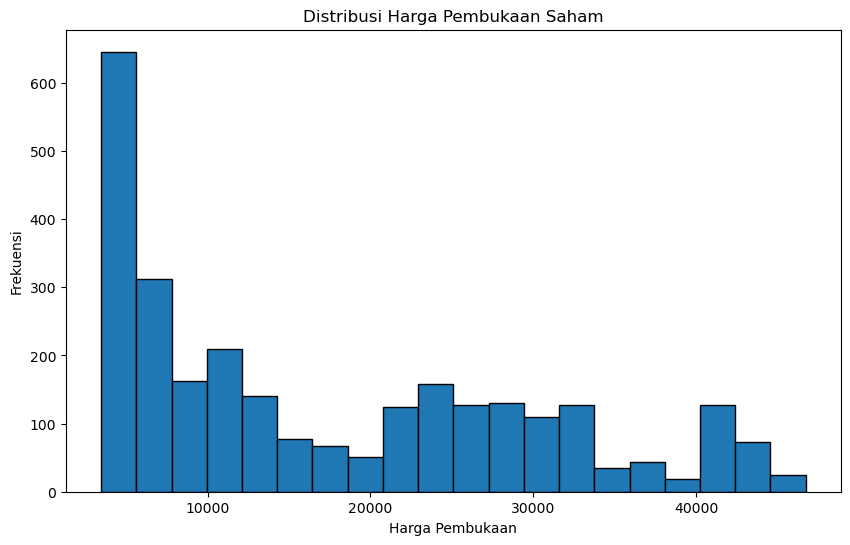

In [48]:
plt.figure(figsize=(10, 6))
plt.hist(df['Pembukaan'], bins=20, edgecolor='k')
plt.title('Distribusi Harga Pembukaan Saham')
plt.xlabel('Harga Pembukaan')
plt.ylabel('Frekuensi')
plt.savefig('foto./distribusi-harga-pembukaan-saham.png')
plt.show()

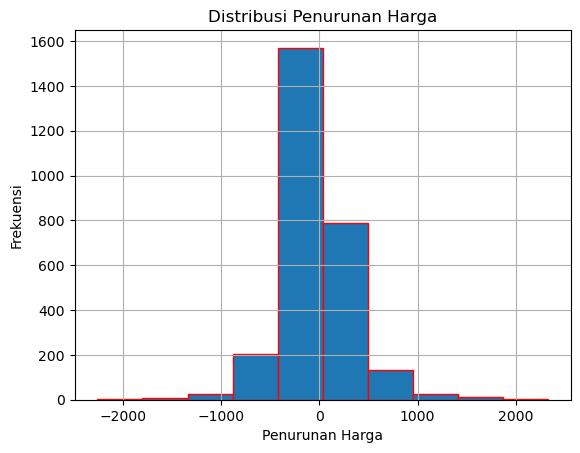

In [49]:
###################

# Analisis Distribusi dan Visualisasi
plt.hist(df['Perubahan Terakhir'], bins=10, edgecolor='red')
plt.title('Distribusi Penurunan Harga')
plt.xlabel('Penurunan Harga')
plt.ylabel('Frekuensi')
plt.savefig('foto./Distribusi Penurunan Harga.png')
plt.grid(True)
plt.show()

In [50]:
df['Perubahan Terakhir'].describe().round(2)

count    2767.00
mean      -14.35
std       339.59
min     -2263.00
25%      -113.00
50%       -10.00
75%        78.00
max      2332.00
Name: Perubahan Terakhir, dtype: float64

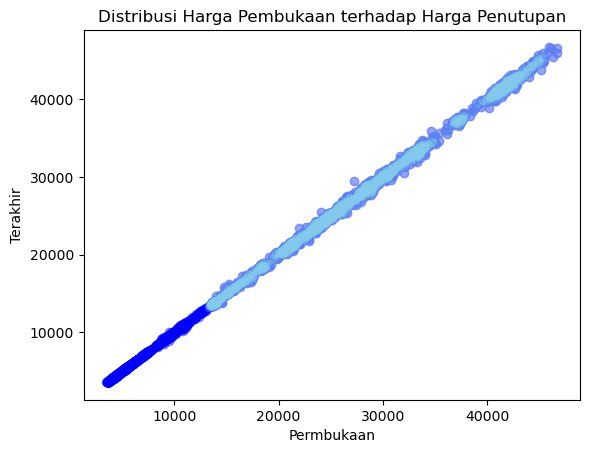

In [51]:
plt.scatter(data=df, x='Pembukaan', y='Terakhir', color='blue', alpha=0.4)
plt.scatter(df['Pembukaan'][:len(df)//2], df['Terakhir'][:len(df)//2], color='skyblue', alpha=0.2)  # Tambah warna kedua

plt.xlabel('Permbukaan')
plt.ylabel('Terakhir')
plt.title('Distribusi Harga Pembukaan terhadap Harga Penutupan')
plt.savefig('foto./Distribusi-Harga-pembukaanterhadap-hargaPenutupan.png')

plt.show()

Text(74.22222222222221, 0.5, 'Frekuensi')

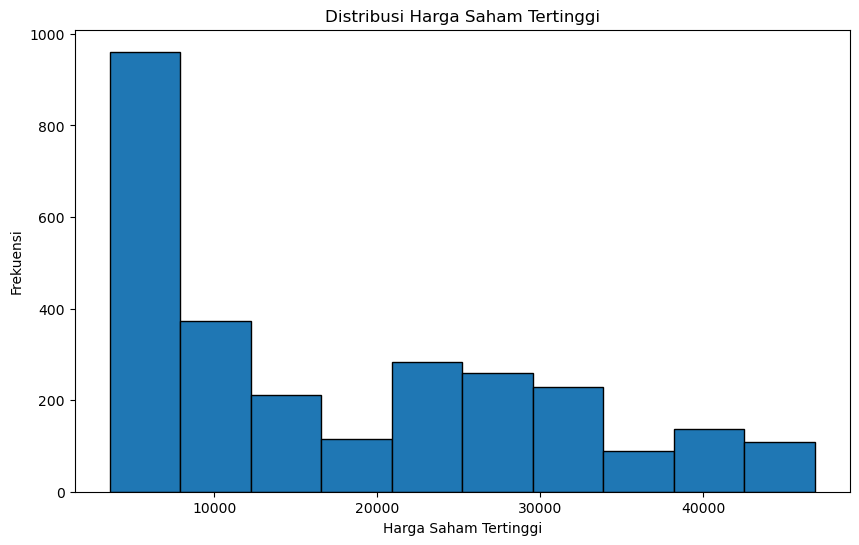

In [52]:
plt.figure(figsize=(10, 6))
plt.hist(df['Tertinggi'], bins=10, edgecolor='k')
plt.title('Distribusi Harga Saham Tertinggi')
plt.xlabel('Harga Saham Tertinggi')
plt.savefig('foto./Distribusi-harga-saham-tertinggi.png')
plt.ylabel('Frekuensi')

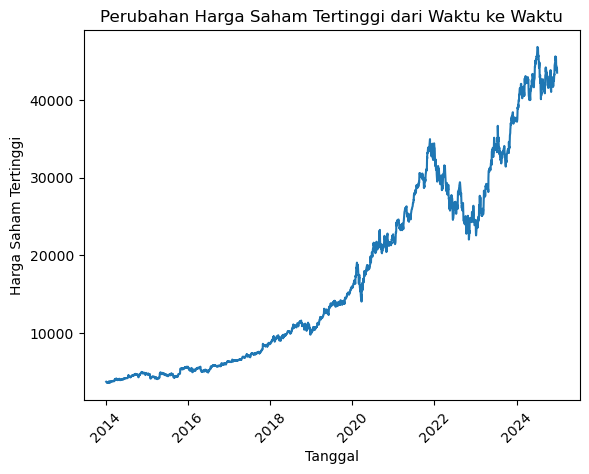

In [53]:
plt.plot(df['Tanggal'], df['Tertinggi'])
plt.title('Perubahan Harga Saham Tertinggi dari Waktu ke Waktu')
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham Tertinggi')
plt.xticks(rotation=45)
plt.savefig('foto./perubahan-harga-saham-tertinggi-waku-kewaktu.png')
plt.show()

In [54]:
#menentukan fitur dan label
#X = df[[ 'Pembukaan', 'Tertinggi', 'Terendah','Vol.','Perubahan%','day','week','month','year']]
#y = df['Terakhir'] # Kolom 'Terakhir/price' menjadi label yang ingin diprediksi

In [55]:
#menentukan fitur dan label
X = df[[ 'Pembukaan', 'Tertinggi', 'Terendah','Vol.','Perubahan%']]
y = df['Terakhir'] # Kolom 'Terakhir/price' menjadi label yang ingin diprediksi

In [56]:
#membagi data menjadi data training dan data testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("input data Training : ",X_train.shape)
print("output data Training : ",y_train.shape)
print("input data test : ",X_test.shape)
print("output data Test : ",y_test.shape)

input data Training :  (2213, 5)
output data Training :  (2213,)
input data test :  (554, 5)
output data Test :  (554,)


In [57]:
#melihat data
print("\n--- 10 baris pertama X_test ---")
print(X_test.head(10))

print("\n--- 10 baris terakhir X_test ---")
print(X_test.tail(10))


--- 10 baris pertama X_test ---
      Pembukaan  Tertinggi  Terendah    Vol.  Perubahan%
1378    13600.0    13697.0   13580.0  1995.0       -0.37
839     30099.0    30243.0   29895.0  1767.0       -0.97
2163     5070.0     5171.0    5040.0  3476.0        3.12
2618     4331.0     4346.0    4283.0  2627.0       -0.67
927     26021.0    26178.0   25564.0  2561.0       -1.31
450     25998.0    26648.0   25921.0  4603.0        1.78
368     33956.0    34374.0   33902.0  2057.0        1.62
1135    20160.0    20325.0   19656.0  3674.0       -2.02
1756     8659.0     8766.0    8657.0  2191.0        0.88
296     33130.0    33184.0   32760.0  3115.0        0.37

--- 10 baris terakhir X_test ---
      Pembukaan  Tertinggi  Terendah    Vol.  Perubahan%
157     41202.0    41749.0   41155.0  1511.0        0.69
1640    10208.0    10246.0   10088.0  2320.0       -0.72
2326     4475.0     4475.0    4375.0  2866.0        0.79
238     39172.0    39399.0   39012.0  2339.0        1.13
2603     4531.0     4

In [58]:
# Ambil 10 baris pertama & 10 baris terakhir dari X_test
#first10 = X_test.head(10)
#last10 = X_test.tail(10)

# Gabungkan menjadi satu DataFrame (opsional: tambahkan kolom penanda apakah baris awal atau akhir)
#first10["bagian"] = "awal"
#last10["bagian"] = "akhir"

#df_to_save = pd.concat([first10, last10])

## Simpan ke Excel
#file_excel = "X_test_pertama_terakhir.xlsx"
#df_to_save.to_excel(file_excel, index=True)  # index=True jika kamu ingin menyimpan indeks asli dari X_test

#print(f"Data telah disimpan ke file: {file_excel}")

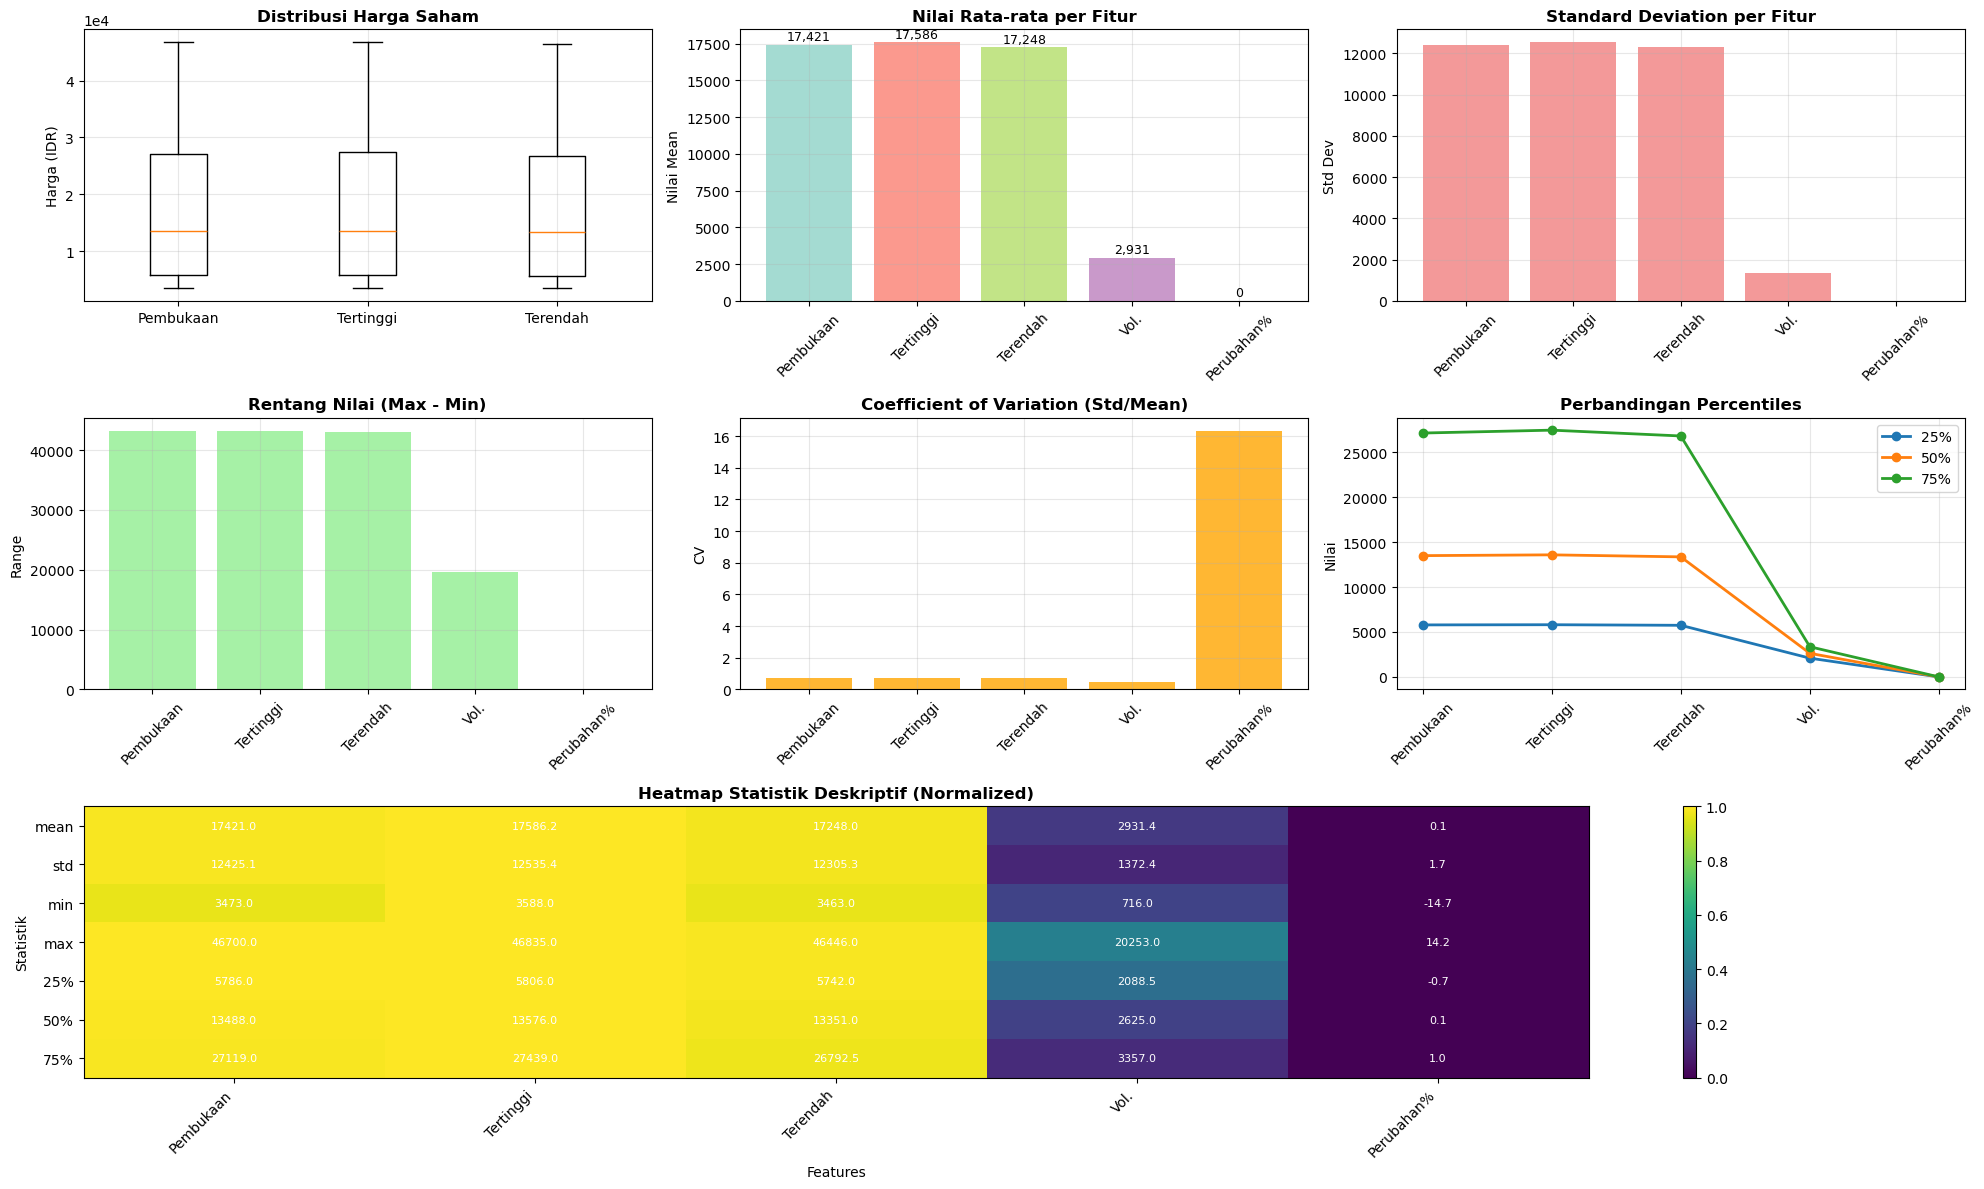

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# Asumsikan X adalah DataFrame Anda
# Dapatkan statistik deskriptif secara otomatis
describe_df = X.describe()
features = describe_df.columns.tolist()

# Ekstrak statistik ke dictionary
stats = {}
for stat in ['mean', 'std', 'min', '25%', '50%', '75%', 'max']:
    stats[stat] = describe_df.loc[stat].values

# Sekarang buat visualisasi
plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=plt.gcf())

# 1. Boxplot untuk Harga Saham
ax1 = plt.subplot(gs[0, 0])
price_features = ['Pembukaan', 'Tertinggi', 'Terendah']
price_indices = [features.index(f) for f in price_features]

price_data = []
for i in price_indices:
    price_data.append([stats['min'][i], stats['25%'][i], stats['50%'][i], stats['75%'][i], stats['max'][i]])

box = ax1.boxplot(price_data, labels=price_features)
ax1.set_title('Distribusi Harga Saham', fontweight='bold', fontsize=12)
ax1.set_ylabel('Harga (IDR)')
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# 2. Bar Chart Mean Values
ax2 = plt.subplot(gs[0, 1])
colors = plt.cm.Set3(np.linspace(0, 1, len(features)))
bars = ax2.bar(features, stats['mean'], color=colors, alpha=0.8)
ax2.set_title('Nilai Rata-rata per Fitur', fontweight='bold', fontsize=12)
ax2.set_ylabel('Nilai Mean')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Tambahkan nilai di atas bar
for bar, value in zip(bars, stats['mean']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

# 3. Standard Deviation Comparison
ax3 = plt.subplot(gs[0, 2])
ax3.bar(features, stats['std'], color='lightcoral', alpha=0.8)
ax3.set_title('Standard Deviation per Fitur', fontweight='bold', fontsize=12)
ax3.set_ylabel('Std Dev')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Range Analysis (Max - Min)
ax4 = plt.subplot(gs[1, 0])
ranges = [stats['max'][i] - stats['min'][i] for i in range(len(features))]
bars = ax4.bar(features, ranges, color='lightgreen', alpha=0.8)
ax4.set_title('Rentang Nilai (Max - Min)', fontweight='bold', fontsize=12)
ax4.set_ylabel('Range')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

# 5. Coefficient of Variation
ax5 = plt.subplot(gs[1, 1])
cv = [stats['std'][i] / abs(stats['mean'][i]) if stats['mean'][i] != 0 else 0 for i in range(len(features))]
ax5.bar(features, cv, color='orange', alpha=0.8)
ax5.set_title('Coefficient of Variation (Std/Mean)', fontweight='bold', fontsize=12)
ax5.set_ylabel('CV')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3)

# 6. Percentile Comparison
ax6 = plt.subplot(gs[1, 2])
percentiles = ['25%', '50%', '75%']
percentile_data = np.array([stats[p] for p in percentiles])
for i, percentile in enumerate(percentiles):
    ax6.plot(features, percentile_data[i], marker='o', label=percentile, linewidth=2)
ax6.set_title('Perbandingan Percentiles', fontweight='bold', fontsize=12)
ax6.set_ylabel('Nilai')
ax6.tick_params(axis='x', rotation=45)
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Heatmap of Statistics
ax7 = plt.subplot(gs[2, :])
stats_types = ['mean', 'std', 'min', 'max', '25%', '50%', '75%']
heatmap_data = np.array([stats[stat] for stat in stats_types])

# Normalize for better visualization
normalized_data = (heatmap_data - heatmap_data.min(axis=1, keepdims=True)) / \
                 (heatmap_data.max(axis=1, keepdims=True) - heatmap_data.min(axis=1, keepdims=True) + 1e-10)

im = ax7.imshow(normalized_data, cmap='viridis', aspect='auto')
ax7.set_title('Heatmap Statistik Deskriptif (Normalized)', fontweight='bold', fontsize=12)
ax7.set_xlabel('Features')
ax7.set_ylabel('Statistik')
ax7.set_xticks(range(len(features)))
ax7.set_xticklabels(features, rotation=45, ha='right')
ax7.set_yticks(range(len(stats_types)))
ax7.set_yticklabels(stats_types)

# Add values to heatmap
for i in range(len(stats_types)):
    for j in range(len(features)):
        text = ax7.text(j, i, f'{heatmap_data[i, j]:.1f}',
                       ha="center", va="center", color="w", fontsize=8)

plt.colorbar(im, ax=ax7)
plt.tight_layout()
plt.savefig('foto./CAMPURAN12345atas.png')
plt.show()

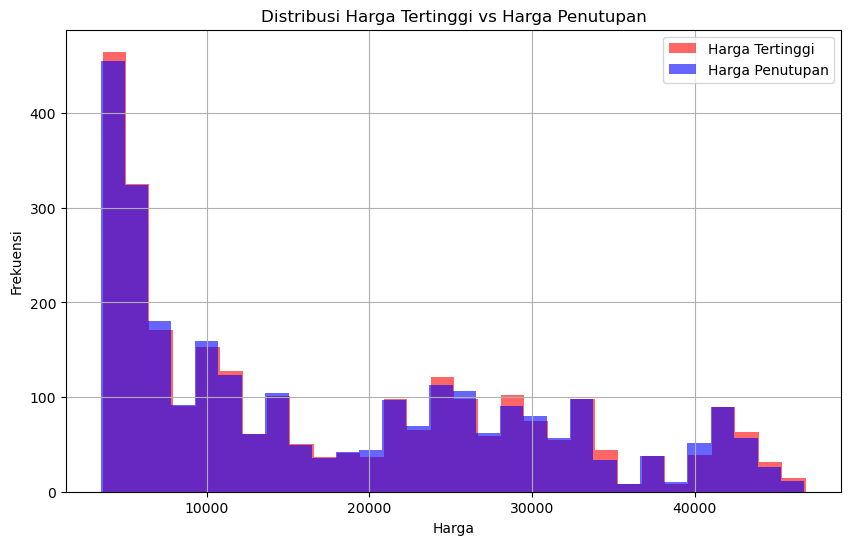

In [60]:
# Pastikan kolom angka sudah float (jika sebelumnya dibersihkan, lewati bagian ini)
df['Tertinggi'] = df['Tertinggi'].astype(float)
df['Terakhir'] = df['Terakhir'].astype(float)

# Plot histogram dua distribusi
plt.figure(figsize=(10, 6))
plt.hist(df['Tertinggi'], bins=30, alpha=0.6, color='red', label='Harga Tertinggi')
plt.hist(df['Terakhir'], bins=30, alpha=0.6, color='blue', label='Harga Penutupan')

plt.title('Distribusi Harga Tertinggi vs Harga Penutupan')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True)
plt.savefig('foto./disribusi-harga-teringgi-vs-harga-penutup.png')
plt.show()

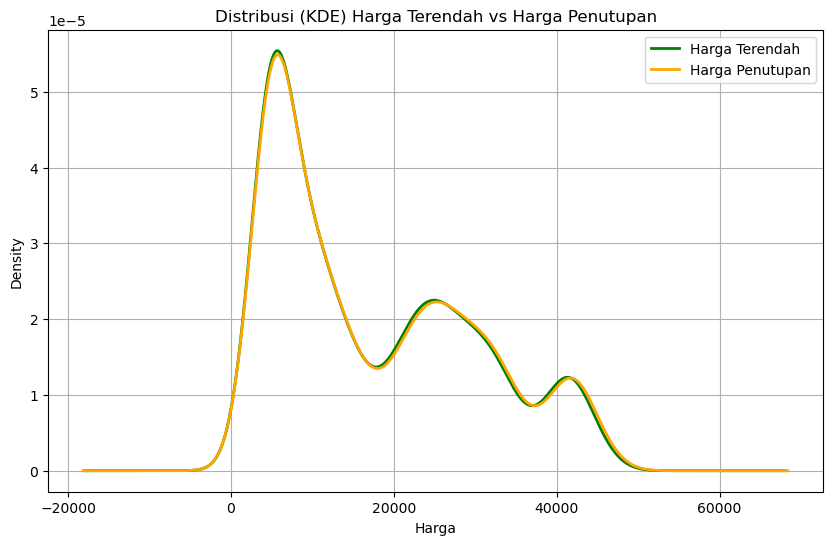

In [61]:
plt.figure(figsize=(10, 6))
df['Terendah'].plot(kind='kde', label='Harga Terendah', linewidth=2, color='green')
df['Terakhir'].plot(kind='kde', label='Harga Penutupan', linewidth=2, color='orange')

plt.title('Distribusi (KDE) Harga Terendah vs Harga Penutupan')
plt.xlabel('Harga')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.savefig('foto./KDE-Harga-Terendah-vs-Harga-Penutupan.png')
plt.show()

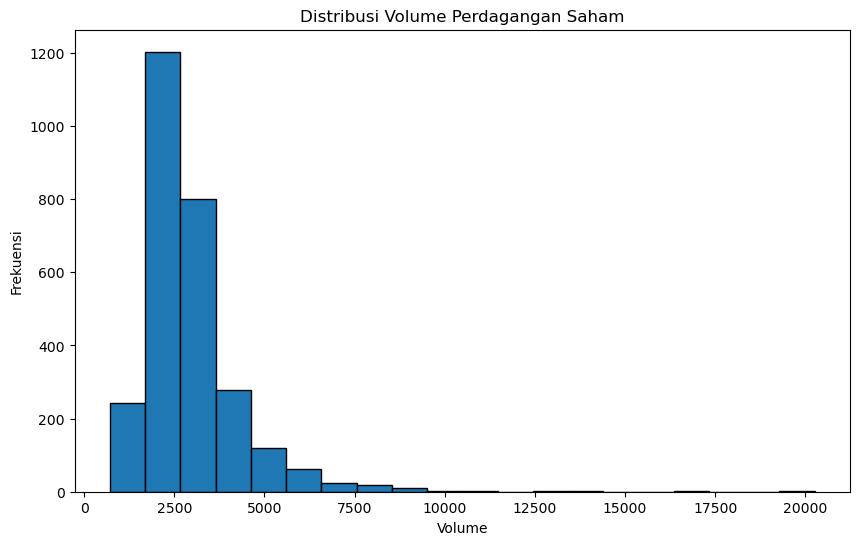

In [62]:

# Plot distribusi Volume
plt.figure(figsize=(10, 6))
plt.hist(df['Vol.'], bins=20, edgecolor='k')
plt.title('Distribusi Volume Perdagangan Saham')
plt.xlabel('Volume')
plt.ylabel('Frekuensi')
plt.savefig('foto./distribusi-volume-saham.png')
plt.show()

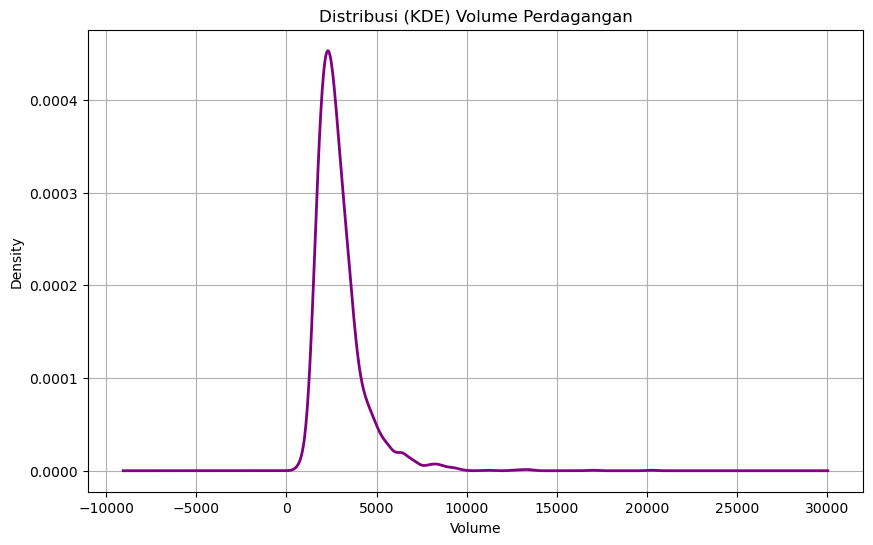

In [63]:
plt.figure(figsize=(10, 6))
df['Vol.'].plot(kind='kde', linewidth=2, color='purple')
plt.title('Distribusi (KDE) Volume Perdagangan')
plt.xlabel('Volume')
plt.ylabel('Density')
plt.grid(True)
plt.savefig('foto./KDE-volume-perdagangan.png')
plt.show()

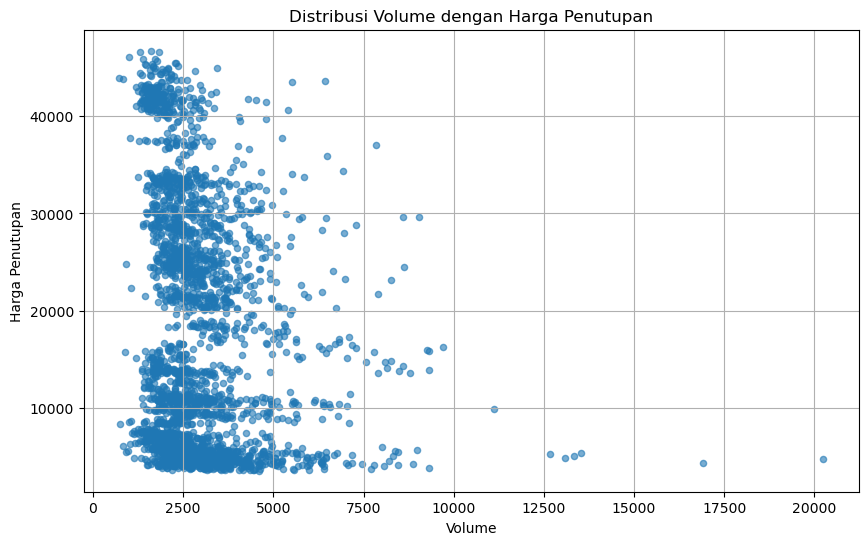

In [64]:
# Asumsi df sudah berisi data dan tipe data sudah dikonversi seperti di kode awal kamu

plt.figure(figsize=(10, 6))
plt.scatter(x=df['Vol.'], y=df['Terakhir'], alpha=0.6, s=20)
plt.title('Distribusi Volume dengan Harga Penutupan')
plt.xlabel('Volume')
plt.ylabel('Harga Penutupan')
plt.grid(True)
plt.savefig('foto./Distribusi-Volume-dengan-Harga-Penutupan.png')
plt.show()

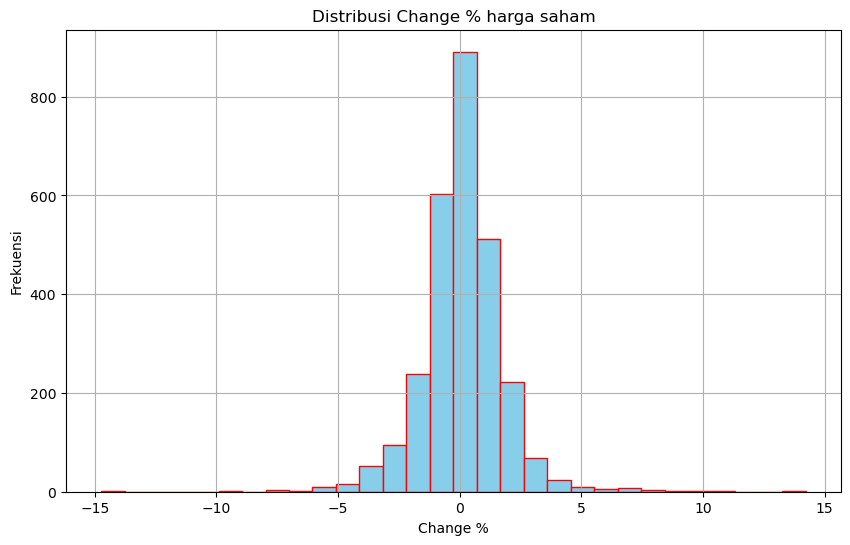

In [65]:
plt.figure(figsize=(10, 6))
plt.hist(df['Perubahan%'], bins=30, color='skyblue', edgecolor='red')
plt.title('Distribusi Change % harga saham')
plt.xlabel('Change %')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.savefig('foto./Distribusi-Change%-harga-saham.png')
plt.show()


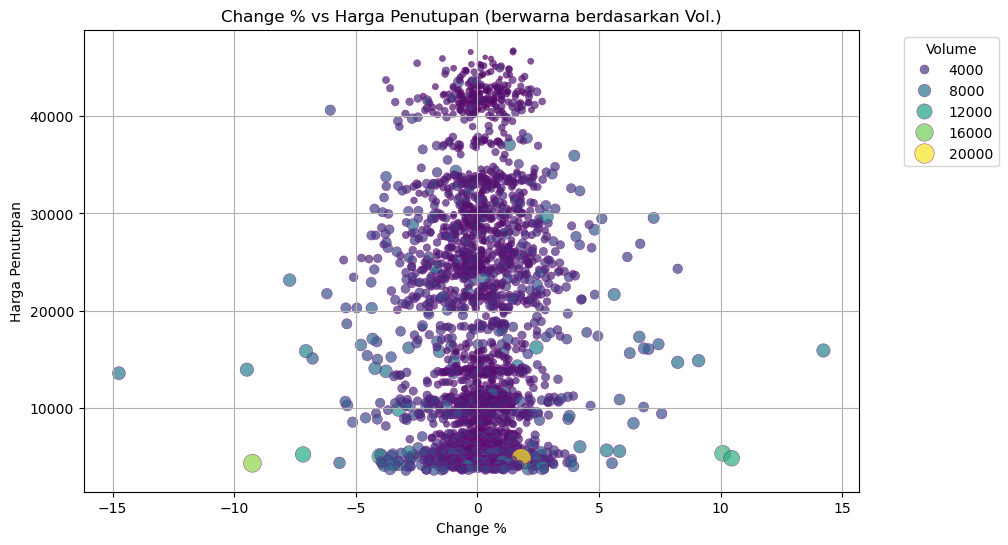

In [66]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Perubahan%',
    y='Terakhir',
    hue='Vol.',  # alternatif: bisa juga 'Tanggal', 'month', dsb.
    palette='viridis',
    size='Vol.',  # atau ukuran berdasarkan kolom lain
    sizes=(10, 200),  # skala ukuran titik
    alpha=0.7,
    edgecolor='purple'
)
plt.title('Change % vs Harga Penutupan (berwarna berdasarkan Vol.)')
plt.xlabel('Change %')
plt.ylabel('Harga Penutupan')
plt.legend(title='Volume', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True)
plt.savefig('foto./Change%-vs-Harga-Penutupan.png')
plt.show()


In [67]:
# Pastikan X_test dan y_test memang berisi 554 data
print(f"X_test shape: {X_test.shape}")  # Harusnya (554, n_features)
print(f"y_test shape: {y_test.shape}")  # Harusnya (554,)

X_test shape: (554, 5)
y_test shape: (554,)


In [68]:
###coba

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. TANPA SCALING
model_no_scaling = LinearRegression()
model_no_scaling.fit(X_train, y_train)
y_pred_no_scaling_train = model_no_scaling.predict(X_train)  # Prediksi data training
y_pred_no_scaling_test = model_no_scaling.predict(X_test)    # Prediksi data testing

# 2. DENGAN PIPELINE SCALING
pipeline = make_pipeline(StandardScaler(), LinearRegression())
pipeline.fit(X_train, y_train)
y_pred_pipeline_train = pipeline.predict(X_train)  # Prediksi data training
y_pred_pipeline_test = pipeline.predict(X_test)    # Prediksi data testing

# EVALUASI FUNCTION
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    accuracy = 100 - mape
    return rmse, mae, mape, accuracy, r2

# Evaluasi pada DATA TRAINING (2213 samples)
results_no_scaling_train = evaluate_model(y_train, y_pred_no_scaling_train)
results_pipeline_train = evaluate_model(y_train, y_pred_pipeline_train)

# Evaluasi pada DATA TESTING (554 samples) - untuk perbandingan
results_no_scaling_test = evaluate_model(y_test, y_pred_no_scaling_test)
results_pipeline_test = evaluate_model(y_test, y_pred_pipeline_test)

# Tampilkan hasil untuk DATA TRAINING
print("=== EVALUASI PADA DATA TRAINING (2213 samples) ===")
print("=== Tanpa Scaling ===")
print(f"RMSE     : {results_no_scaling_train[0]:.12f}")
print(f"MAE      : {results_no_scaling_train[1]:.12f}")
print(f"MAPE     : {results_no_scaling_train[2]:.2f}%")
print(f"Akurasi  : {results_no_scaling_train[3]:.2f}%")
print(f"R-squared: {results_no_scaling_train[4]:.4f}")

print("\n=== Dengan Pipeline Scaling ===")
print(f"RMSE     : {results_pipeline_train[0]:.12f}")
print(f"MAE      : {results_pipeline_train[1]:.12f}")
print(f"MAPE     : {results_pipeline_train[2]:.2f}%")
print(f"Akurasi  : {results_pipeline_train[3]:.2f}%")
print(f"R-squared: {results_pipeline_train[4]:.4f}")

# Tampilkan hasil untuk DATA TESTING (sebagai perbandingan)
print("\n" + "="*60)
print("=== PERBANDINGAN: TRAINING vs TESTING ===")
print("=== Tanpa Scaling ===")
print(f"R-squared Training : {results_no_scaling_train[4]:.4f}")
print(f"R-squared Testing  : {results_no_scaling_test[4]:.4f}")
print(f"Selisih            : {results_no_scaling_train[4] - results_no_scaling_test[4]:.4f}")

print("\n=== Dengan Pipeline Scaling ===")
print(f"R-squared Training : {results_pipeline_train[4]:.4f}")
print(f"R-squared Testing  : {results_pipeline_test[4]:.4f}")
print(f"Selisih            : {results_pipeline_train[4] - results_pipeline_test[4]:.4f}")

# Verifikasi jumlah data
print(f"\nJumlah Data Training: {len(y_train)} samples")
print(f"Jumlah Data Testing : {len(y_test)} samples")
print(f"Total Data         : {len(y_train) + len(y_test)} samples")

=== EVALUASI PADA DATA TRAINING (2213 samples) ===
=== Tanpa Scaling ===
RMSE     : 109.485176510610
MAE      : 70.228982137650
MAPE     : 0.47%
Akurasi  : 99.53%
R-squared: 0.9999

=== Dengan Pipeline Scaling ===
RMSE     : 109.485176510610
MAE      : 70.228982137650
MAPE     : 0.47%
Akurasi  : 99.53%
R-squared: 0.9999

=== PERBANDINGAN: TRAINING vs TESTING ===
=== Tanpa Scaling ===
R-squared Training : 0.9999
R-squared Testing  : 0.9999
Selisih            : -0.0000

=== Dengan Pipeline Scaling ===
R-squared Training : 0.9999
R-squared Testing  : 0.9999
Selisih            : -0.0000

Jumlah Data Training: 2213 samples
Jumlah Data Testing : 554 samples
Total Data         : 2767 samples


In [70]:
#data testing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. TANPA SCALING
model_no_scaling = LinearRegression()
model_no_scaling.fit(X_train, y_train)
y_pred_no_scaling = model_no_scaling.predict(X_test )

# 2. DENGAN PIPELINE SCALING
pipeline = make_pipeline(StandardScaler(), LinearRegression())
pipeline.fit(X_train, y_train)
y_pred_pipeline = pipeline.predict(X_test)

# EVALUASI FUNCTION
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    accuracy = 100 - mape
    return rmse, mae, mape, accuracy, r2

# Evaluasi pada DATA TESTING saja
results_no_scaling = evaluate_model(y_test, y_pred_no_scaling)
results_pipeline = evaluate_model(y_test, y_pred_pipeline)

# Tampilkan hasil untuk 554 data testing
print("=== Evaluasi pada Data Testing (554 samples) ===")
print("=== Tanpa Scaling ===")
print(f"RMSE     : {results_no_scaling[0]:.12f}")
print(f"MAE      : {results_no_scaling[1]:.12f}")
print(f"MAPE     : {results_no_scaling[2]:.2f}%")
print(f"Akurasi  : {results_no_scaling[3]:.2f}%")
print(f"R-squared: {results_no_scaling[4]:.4f}")

print("\n=== Dengan Pipeline Scaling ===")
print(f"RMSE     : {results_pipeline[0]:.12f}")
print(f"MAE      : {results_pipeline[1]:.12f}")
print(f"MAPE     : {results_pipeline[2]:.2f}%")
print(f"Akurasi  : {results_pipeline[3]:.2f}%")
print(f"R-squared: {results_pipeline[4]:.4f}")

# Verifikasi jumlah data testing
print(f"\nJumlah Data Testing: {len(y_test)} samples")

=== Evaluasi pada Data Testing (554 samples) ===
=== Tanpa Scaling ===
RMSE     : 103.536983816918
MAE      : 70.569754640871
MAPE     : 0.50%
Akurasi  : 99.50%
R-squared: 0.9999

=== Dengan Pipeline Scaling ===
RMSE     : 103.536983816917
MAE      : 70.569754640870
MAPE     : 0.50%
Akurasi  : 99.50%
R-squared: 0.9999

Jumlah Data Testing: 554 samples


In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Dapatkan koefisien dari kedua model
coef_no_scaling = model_no_scaling.coef_
coef_with_scaling = pipeline.named_steps['linearregression'].coef_

# Nama feature sesuai dengan urutan Anda
feature_names = ['Pembukaan', 'Tertinggi', 'Terendah', 'Vol.', 'Perubahan%']

print("=== PERBANDINGAN KOEFISIEN ===")
print(f"{'Feature':<15} {'Tanpa Scaling':<20} {'Dengan Scaling':<20} {'Ratio':<10}")
print("-" * 70)

for i, feature in enumerate(feature_names):
    ratio = coef_with_scaling[i] / coef_no_scaling[i] if coef_no_scaling[i] != 0 else np.inf
    print(f"{feature:<15} {coef_no_scaling[i]:<20.6f} {coef_with_scaling[i]:<20.6f} {ratio:<10.2f}")

# Cek apakah prediksi benar-benar sama
print(f"\nPrediksi identik? {np.allclose(y_pred_no_scaling, y_pred_pipeline, rtol=1e-10)}")

=== PERBANDINGAN KOEFISIEN ===
Feature         Tanpa Scaling        Dengan Scaling       Ratio     
----------------------------------------------------------------------
Pembukaan       -0.402298            -4998.920594         12425.92  
Tertinggi       0.672665             8434.224212          12538.52  
Terendah        0.730548             8989.965619          12305.79  
Vol.            -0.001848            -2.489517            1347.49   
Perubahan%      39.433030            64.739052            1.64      

Prediksi identik? True


In [72]:
#plt.figure(figsize=(15, 10))

# Plot 1: Koefisien Tanpa Scaling
#plt.subplot(2, 2, 1)
#bars1 = plt.barh(feature_names, coef_no_scaling, color='skyblue')
#plt.title('Koefisien Tanpa Scaling')
#plt.xlabel('Nilai Koefisien')
#plt.grid(axis='x', alpha=0.3)
# Tambahkan nilai pada bar
#for bar in bars1:
#    width = bar.get_width()
#    plt.text(width, bar.get_y() + bar.get_height()/2, 
#             f'{width:.2f}', ha='left', va='center')

# Plot 2: Koefisien Dengan Scaling
#plt.subplot(2, 2, 2)
#bars2 = plt.barh(feature_names, coef_with_scaling, color='lightcoral')
#plt.title('Koefisien Dengan Scaling')
#plt.xlabel('Nilai Koefisien')
#plt.grid(axis='x', alpha=0.3)
# Tambahkan nilai pada bar
#for bar in bars2:
#    width = bar.get_width()
#    plt.text(width, bar.get_y() + bar.get_height()/2, 
#             f'{width:.2f}', ha='left', va='center')

# Plot 3: Perbandingan Side-by-Side
#plt.subplot(2, 1, 2)
#x = np.arange(len(feature_names))
#width = 0.35

#plt.bar(x - width/2, coef_no_scaling, width, label='Tanpa Scaling', alpha=0.8)
#plt.bar(x + width/2, coef_with_scaling, width, label='Dengan Scaling', alpha=0.8)

#plt.xlabel('Features')
#plt.ylabel('Nilai Koefisien')
#plt.title('Perbandingan Koefisien: Tanpa vs Dengan Scaling')
#plt.xticks(x, feature_names, rotation=45, ha='right')
#plt.legend()
#plt.grid(alpha=0.3)
#plt.tight_layout()
#plt.savefig('foto./koefisien_dengan_dan_tanpaScaling.png')

#plt.show()

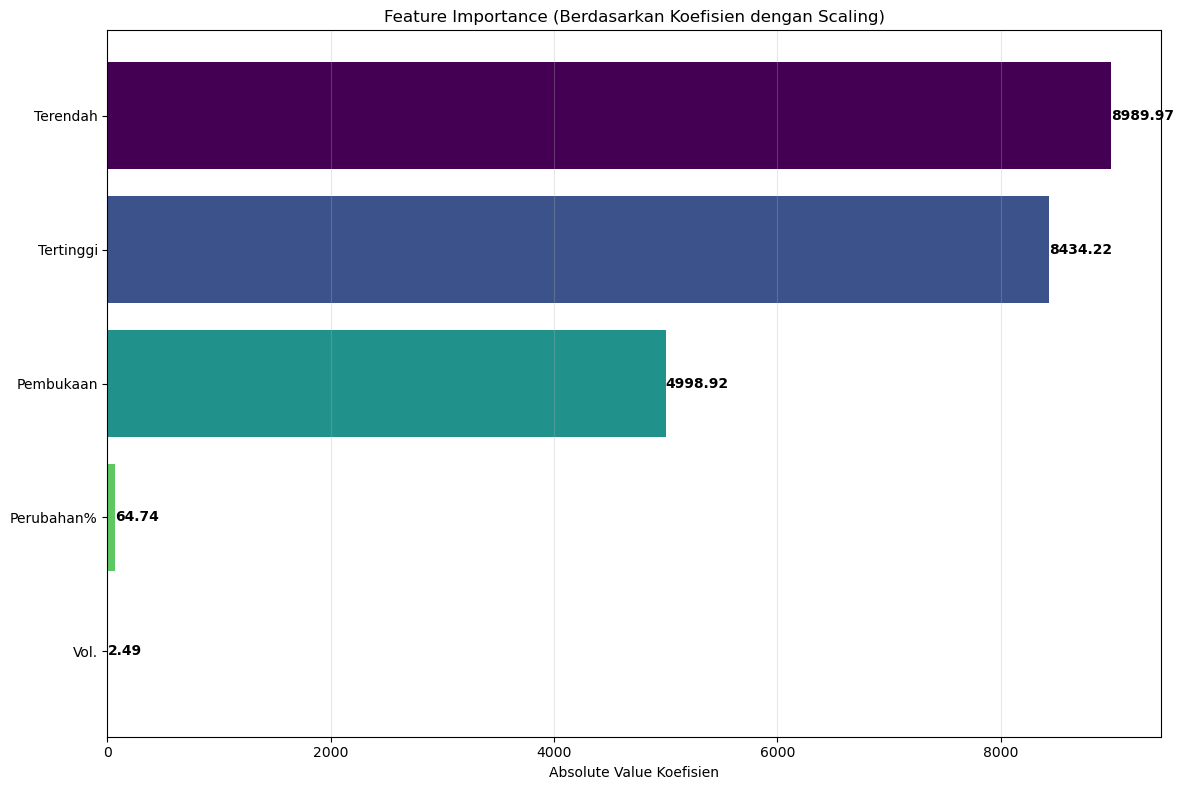

In [73]:
# Feature importance berdasarkan absolute value koefisien dengan scaling
plt.figure(figsize=(12, 8))

feature_importance = np.abs(coef_with_scaling)
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = feature_importance[sorted_idx]

colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_features)))

plt.barh(sorted_features, sorted_importance, color=colors)
plt.title('Feature Importance (Berdasarkan Koefisien dengan Scaling)')
plt.xlabel('Absolute Value Koefisien')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Tambahkan nilai
for i, (feature, importance) in enumerate(zip(sorted_features, sorted_importance)):
    plt.text(importance, i, f'{importance:.2f}', va='center', ha='left', fontweight='bold')
plt.tight_layout()

plt.savefig('foto./absolute value koefisien dengan scaling.png')
plt.show()

In [74]:
#data uji
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 1. TANPA SCALING
model_no_scaling = LinearRegression()
model_no_scaling.fit(X_train, y_train)
y_pred_no_scaling = model_no_scaling.predict(X_test)

# 2. DENGAN PIPELINE
pipeline = make_pipeline(StandardScaler(), LinearRegression())
pipeline.fit(X_train, y_train)
y_pred_pipeline = pipeline.predict(X_test)

# Normalisasi target variable untuk mendapatkan RMSE dan MAE ternormalisasi
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Prediksi dengan model yang sudah fit, lalu normalisasi prediksi
y_pred_no_scaling_scaled = scaler_y.transform(y_pred_no_scaling.reshape(-1, 1)).flatten()
y_pred_pipeline_scaled = scaler_y.transform(y_pred_pipeline.reshape(-1, 1)).flatten()

# EVALUASI FUNCTION dengan normalisasi
def evaluate_model_normalized(y_true, y_pred, y_true_original, y_pred_original):
    # Metrik asli (untuk interpretasi)
    rmse_original = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
    mae_original = mean_absolute_error(y_true_original, y_pred_original)
    
    # Metrik ternormalisasi (skala 0-1)
    rmse_normalized = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_normalized = mean_absolute_error(y_true, y_pred)
    
    mape = np.mean(np.abs((y_true_original - y_pred_original) / y_true_original)) * 100
    r2 = r2_score(y_true_original, y_pred_original)
    accuracy = 100 - mape
    
    return (rmse_original, mae_original, rmse_normalized, mae_normalized, 
            mape, accuracy, r2)

# Evaluasi semua
results_no_scaling = evaluate_model_normalized(y_test_scaled, y_pred_no_scaling_scaled, 
                                             y_test, y_pred_no_scaling)
results_pipeline = evaluate_model_normalized(y_test_scaled, y_pred_pipeline_scaled,
                                           y_test, y_pred_pipeline)

# Tampilkan hasil
print("=== Tanpa Scaling ===")
print(f"RMSE (Original) : {results_no_scaling[0]:.12f}")
print(f"MAE (Original)  : {results_no_scaling[1]:.12f}")
print(f"RMSE (0-1)      : {results_no_scaling[2]:.12f}")
print(f"MAE (0-1)       : {results_no_scaling[3]:.12f}")
print(f"MAPE            : {results_no_scaling[4]:.2f}%")
print(f"Akurasi         : {results_no_scaling[5]:.2f}%")
print(f"R-squared       : {results_no_scaling[6]:.4f}")

print("\n=== Dengan Pipeline Scaling ===")
print(f"RMSE (Original) : {results_pipeline[0]:.12f}")
print(f"MAE (Original)  : {results_pipeline[1]:.12f}")
print(f"RMSE (0-1)      : {results_pipeline[2]:.12f}")
print(f"MAE (0-1)       : {results_pipeline[3]:.12f}")
print(f"MAPE            : {results_pipeline[4]:.2f}%")
print(f"Akurasi         : {results_pipeline[5]:.2f}%")
print(f"R-squared       : {results_pipeline[6]:.4f}")

# Cross-validation dengan data ternormalisasi
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Normalisasi seluruh dataset untuk cross-validation
X_norm = X.copy()
y_norm = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

# Cross-validation untuk model tanpa scaling pada data ternormalisasi
cv_scores_no_scaling = cross_val_score(LinearRegression(), X_norm, y_norm, 
                                      cv=kf, scoring='r2')

# Cross-validation untuk pipeline pada data ternormalisasi
cv_scores_pipeline = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()), 
                                    X_norm, y_norm, cv=kf, scoring='r2')

print("\n=== CROSS-VALIDATION (Data Ternormalisasi) ===")
print(f"CV R² tanpa scaling: {cv_scores_no_scaling.mean():.4f} (±{cv_scores_no_scaling.std():.4f})")
print(f"CV R² dengan scaling: {cv_scores_pipeline.mean():.4f} (±{cv_scores_pipeline.std():.4f})")

print("\n=== PENJELASAN ===")
print("RMSE dan MAE (0-1) dihitung pada data yang telah dinormalisasi ke skala [0,1].")
print("Nilai ini memudahkan perbandingan antar dataset yang berbeda.")
print("MAPE menunjukkan rata-rata kesalahan prediksi dalam persen.")

=== Tanpa Scaling ===
RMSE (Original) : 103.536983816918
MAE (Original)  : 70.569754640871
RMSE (0-1)      : 0.002393475977
MAE (0-1)       : 0.001631368871
MAPE            : 0.50%
Akurasi         : 99.50%
R-squared       : 0.9999

=== Dengan Pipeline Scaling ===
RMSE (Original) : 103.536983816917
MAE (Original)  : 70.569754640870
RMSE (0-1)      : 0.002393475977
MAE (0-1)       : 0.001631368871
MAPE            : 0.50%
Akurasi         : 99.50%
R-squared       : 0.9999

=== CROSS-VALIDATION (Data Ternormalisasi) ===
CV R² tanpa scaling: 0.9999 (±0.0000)
CV R² dengan scaling: 0.9999 (±0.0000)

=== PENJELASAN ===
RMSE dan MAE (0-1) dihitung pada data yang telah dinormalisasi ke skala [0,1].
Nilai ini memudahkan perbandingan antar dataset yang berbeda.
MAPE menunjukkan rata-rata kesalahan prediksi dalam persen.


In [75]:
from sklearn.model_selection import train_test_split

# Contoh: misalnya X dan y sudah didefinisikan sebelumnya
# X = df.drop("target", axis=1)
# y = df["target"]

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Hitung total data
total_data = len(X)

# Hitung jumlah data training dan testing
jumlah_train = len(X_train)
jumlah_test = len(X_test)

# Hitung dalam persen
persen_train = (jumlah_train / total_data) * 100
persen_test = (jumlah_test / total_data) * 100

# Tampilkan hasil
print("=== Pembagian Data ===")
print(f"Total Data           : {total_data}")
print(f"Jumlah Data Training : {jumlah_train} ({persen_train:.1f}%)")
print(f"Jumlah Data Testing  : {jumlah_test} ({persen_test:.1f}%)")


=== Pembagian Data ===
Total Data           : 2767
Jumlah Data Training : 2213 (80.0%)
Jumlah Data Testing  : 554 (20.0%)


In [76]:
print("Rentang nilai per fitur:")
print(X.describe())


Rentang nilai per fitur:
          Pembukaan     Tertinggi      Terendah          Vol.   Perubahan%
count   2767.000000   2767.000000   2767.000000   2767.000000  2767.000000
mean   17420.957355  17586.192627  17248.039393   2931.384893     0.102172
std    12425.068907  12535.402958  12305.312925   1372.407008     1.670089
min     3473.000000   3588.000000   3463.000000    716.000000   -14.740000
25%     5786.000000   5806.000000   5742.000000   2088.500000    -0.675000
50%    13488.000000  13576.000000  13351.000000   2625.000000     0.080000
75%    27119.000000  27439.000000  26792.500000   3357.000000     0.960000
max    46700.000000  46835.000000  46446.000000  20253.000000    14.220000


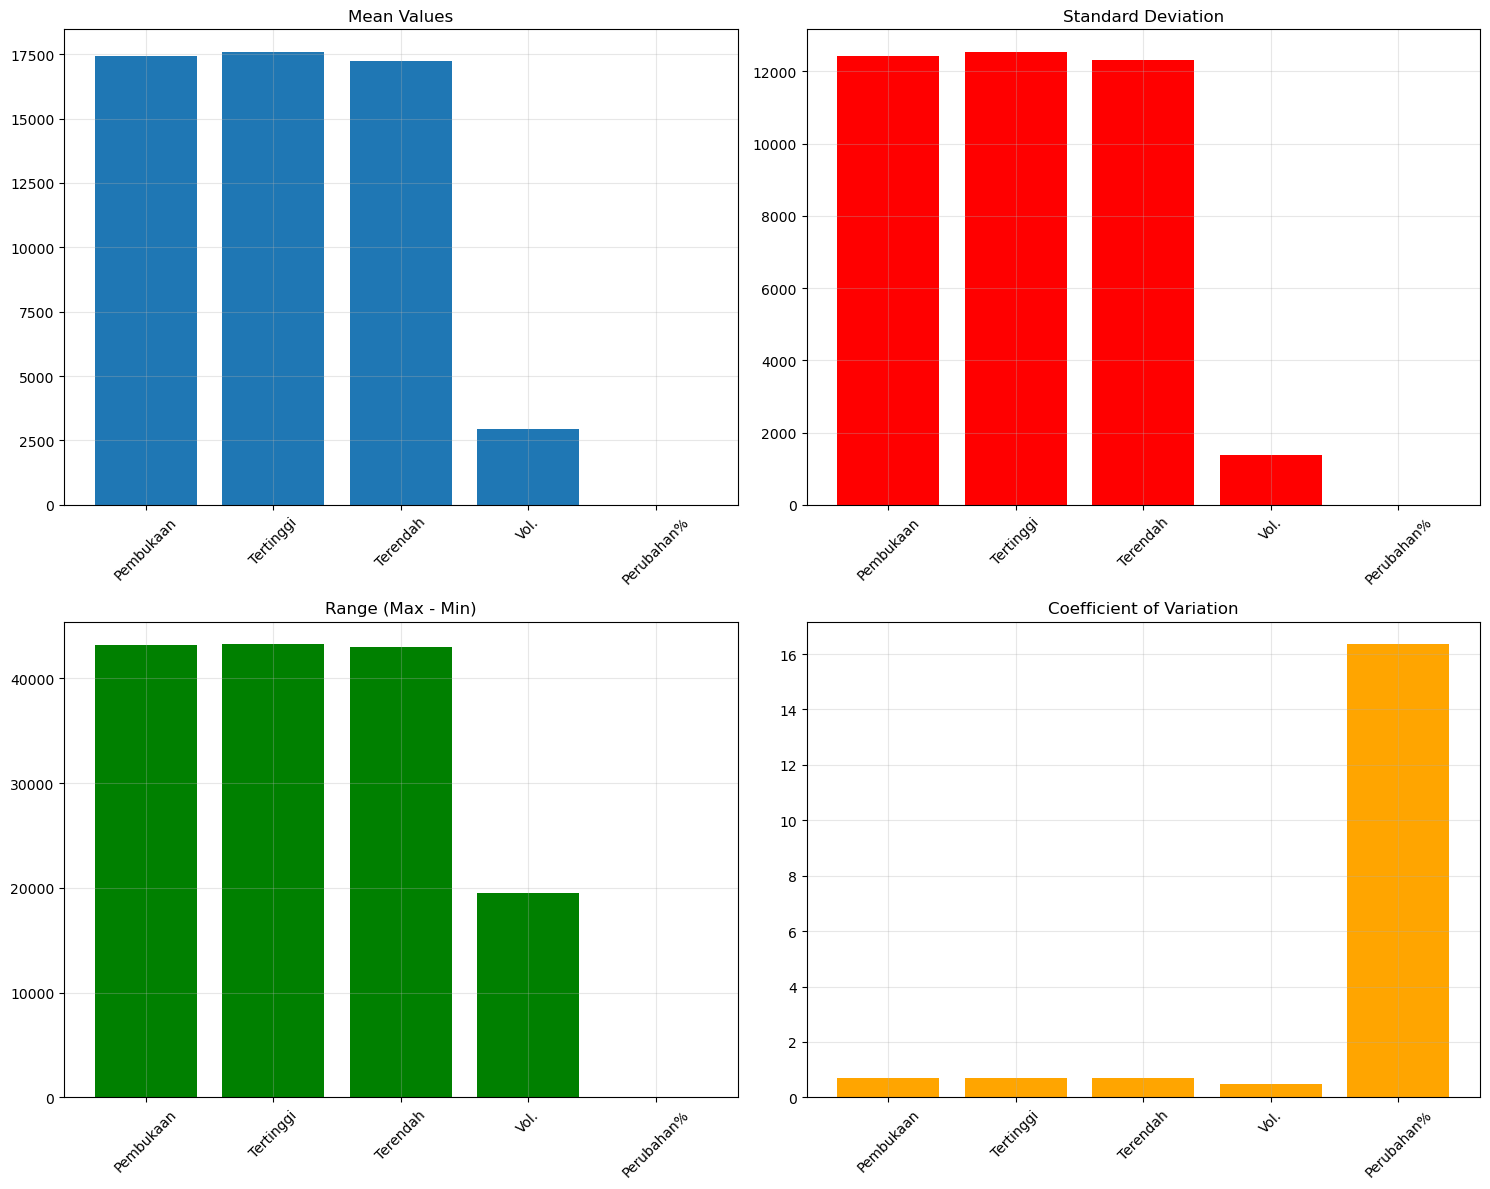

Statistik Deskriptif:
          Pembukaan     Tertinggi      Terendah          Vol.   Perubahan%
count   2767.000000   2767.000000   2767.000000   2767.000000  2767.000000
mean   17420.957355  17586.192627  17248.039393   2931.384893     0.102172
std    12425.068907  12535.402958  12305.312925   1372.407008     1.670089
min     3473.000000   3588.000000   3463.000000    716.000000   -14.740000
25%     5786.000000   5806.000000   5742.000000   2088.500000    -0.675000
50%    13488.000000  13576.000000  13351.000000   2625.000000     0.080000
75%    27119.000000  27439.000000  26792.500000   3357.000000     0.960000
max    46700.000000  46835.000000  46446.000000  20253.000000    14.220000


In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Langsung gunakan describe_df untuk visualisasi
describe_df = X.describe()
features = describe_df.columns.tolist()

# Visualisasi cepat dengan subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Mean values
axes[0,0].bar(features, describe_df.loc['mean'])
axes[0,0].set_title('Mean Values')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Standard deviation
axes[0,1].bar(features, describe_df.loc['std'], color='red')
axes[0,1].set_title('Standard Deviation')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 3. Range (Max - Min)
ranges = describe_df.loc['max'] - describe_df.loc['min']
axes[1,0].bar(features, ranges, color='green')
axes[1,0].set_title('Range (Max - Min)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 4. Coefficient of Variation
cv = describe_df.loc['std'] / describe_df.loc['mean']
axes[1,1].bar(features, cv, color='orange')
axes[1,1].set_title('Coefficient of Variation')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tampilkan tabel statistik juga
print("Statistik Deskriptif:")
print(describe_df)

In [78]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test,
    'Pred Tanpa Scaling': y_pred_no_scaling,
    'Pred Pipeline (Scaling)': y_pred_pipeline,
    'Perbedaan (%)': np.abs((y_pred_no_scaling - y_pred_pipeline) / y_test) * 100
})

print(comparison.head(10))
print(comparison.tail(10))
print("\nRata-rata perbedaan prediksi (dalam %):", comparison['Perbedaan (%)'].mean())


# asumsi comparison sudah dibuat seperti sebelumnya

# Nama file Excel
filename = "comparison_predictions.xlsx"

# Menyimpan ke Excel
comparison.to_excel(filename, index=False)

print(f"Data comparison telah disimpan ke file: {filename}")


       Actual  Pred Tanpa Scaling  Pred Pipeline (Scaling)  Perbedaan (%)
1378  13646.0        13648.153386             13648.153386   3.998951e-14
839   29909.0        30036.205451             30036.205451   2.432698e-14
2163   5159.0         5240.618938              5240.618938   1.762928e-13
2618   4308.0         4282.061073              4282.061073   2.533411e-13
927   25717.0        25763.516121             25763.516121   1.414620e-14
450   26544.0        26467.802529             26467.802529   2.741093e-14
368   34266.0        34292.222674             34292.222674   4.246750e-14
1135  19784.0        19838.145298             19838.145298   0.000000e+00
1756   8711.0         8771.438183              8771.438183   1.252891e-13
296   33053.0        32938.517761             32938.517761   4.402600e-14
       Actual  Pred Tanpa Scaling  Pred Pipeline (Scaling)  Perbedaan (%)
157   41656.0        41601.076244             41601.076244   3.493354e-14
1640  10114.0        10125.905781     

In [79]:
import pandas as pd
import numpy as np

# Asumsikan y_test, y_pred_no_scaling, y_pred_pipeline sudah ada
comparison = pd.DataFrame({
    'Actual': y_test,
    'Pred Tanpa Scaling': y_pred_no_scaling,
    'Pred Pipeline (Scaling)': y_pred_pipeline,
    'Perbedaan (%)': np.abs((y_pred_no_scaling - y_pred_pipeline) / y_test) * 100
})

# Hitung rata-rata perbedaan
rata2 = comparison['Perbedaan (%)'].mean()

print(comparison.head(10))
print("\nRata-rata perbedaan prediksi (dalam %):", rata2)

# Simpan ke Excel
#filename = "perbandingan_prediksi.xlsx"

#with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
    # sheet untuk tabel perbandingan
 #   comparison.to_excel(writer, sheet_name='Perbandingan', index=False)
    
    # Jika kamu ingin juga menyimpan rata-rata perbedaan sebagai nilai di sheet lain:
    # Buat DataFrame kecil untuk rata2
 #   df_rata = pd.DataFrame({
   #     'Keterangan': ['Rata-rata Perbedaan (%)'],
  #      'Nilai': [rata2]
  #  })
   # df_rata.to_excel(writer, sheet_name='Ringkasan', index=False)

#print(f"Data dan ringkasan telah disimpan ke file Excel: {filename}")


       Actual  Pred Tanpa Scaling  Pred Pipeline (Scaling)  Perbedaan (%)
1378  13646.0        13648.153386             13648.153386   3.998951e-14
839   29909.0        30036.205451             30036.205451   2.432698e-14
2163   5159.0         5240.618938              5240.618938   1.762928e-13
2618   4308.0         4282.061073              4282.061073   2.533411e-13
927   25717.0        25763.516121             25763.516121   1.414620e-14
450   26544.0        26467.802529             26467.802529   2.741093e-14
368   34266.0        34292.222674             34292.222674   4.246750e-14
1135  19784.0        19838.145298             19838.145298   0.000000e+00
1756   8711.0         8771.438183              8771.438183   1.252891e-13
296   33053.0        32938.517761             32938.517761   4.402600e-14

Rata-rata perbedaan prediksi (dalam %): 9.378820227523376e-14


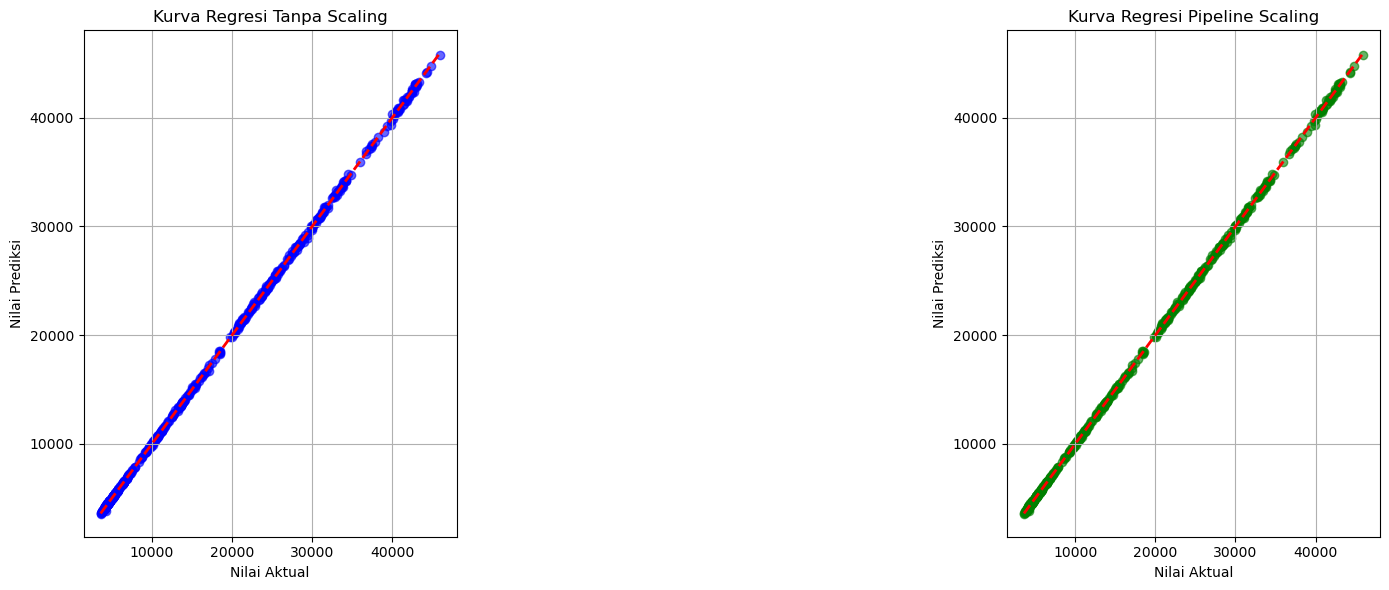

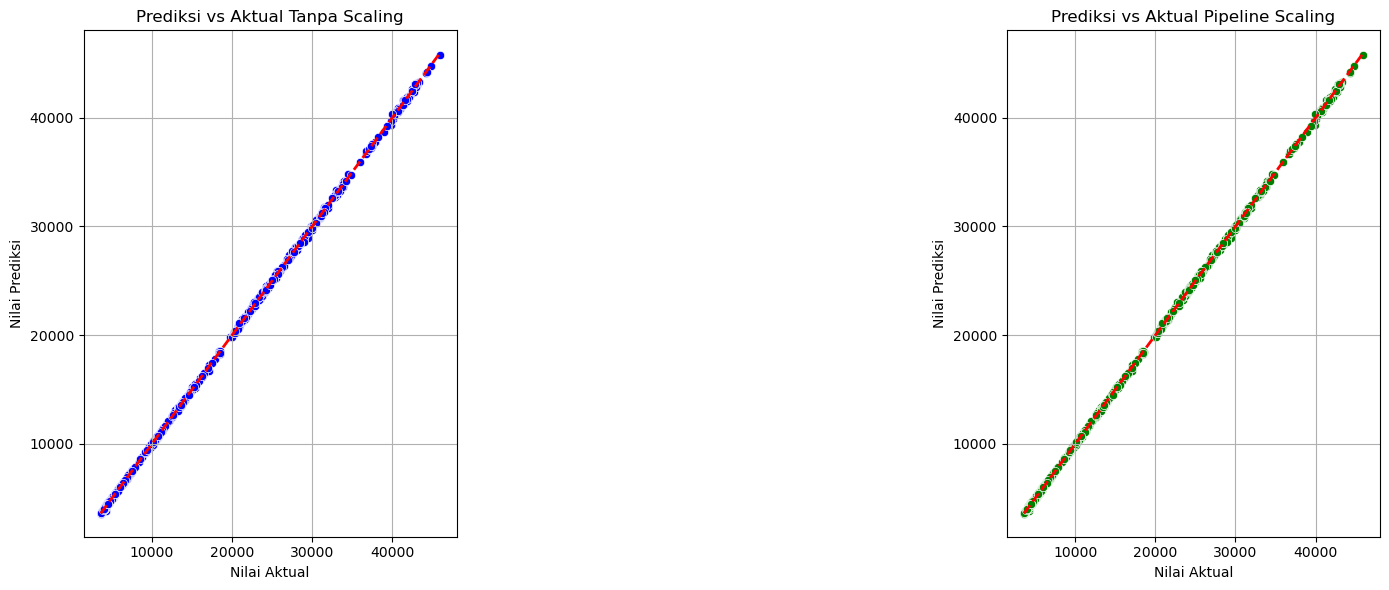

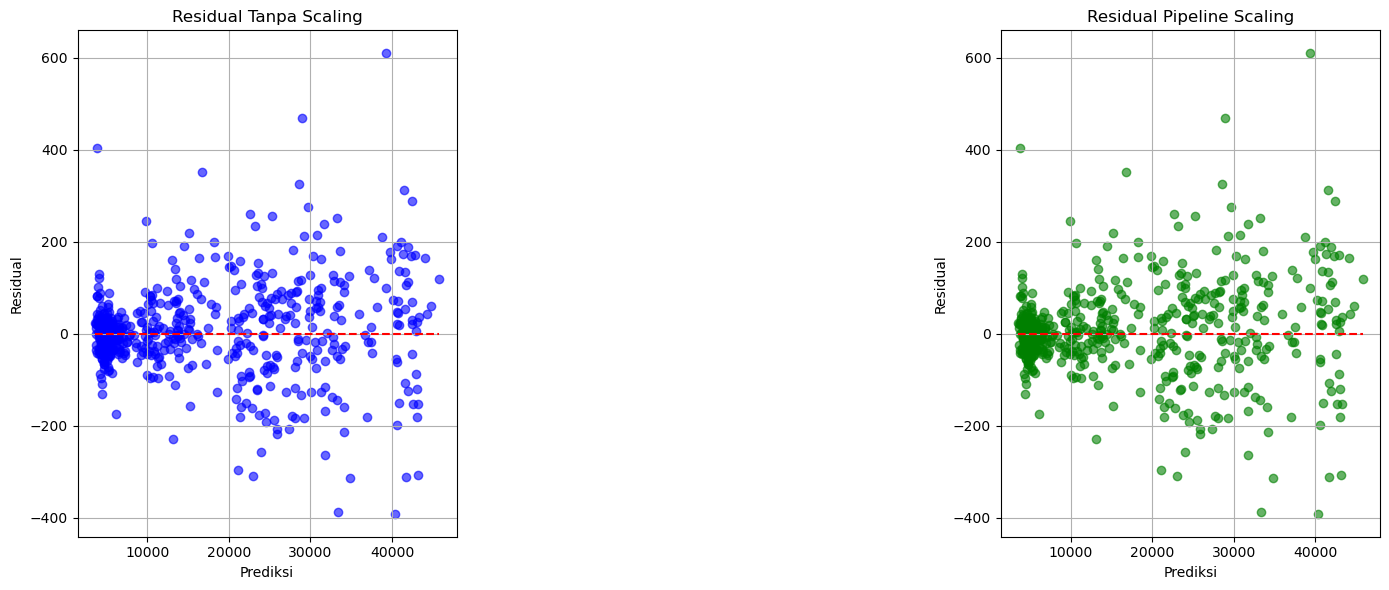

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grafik Kurva Regresi
plt.figure(figsize=(14, 6))

# Kurva regresi Tanpa Scaling
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_no_scaling, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # Garis ideal
plt.title('Kurva Regresi Tanpa Scaling')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.grid(True)

# Kurva regresi Manual Scaling
#plt.subplot(1, 3, 2)
#plt.scatter(y_test, y_pred_manual, color='green', alpha=0.6)
#plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # Garis ideal
#plt.title('Kurva Regresi Manual Scaling')
#plt.xlabel('Nilai Aktual')
#plt.ylabel('Nilai Prediksi')
#plt.grid(True)

# Kurva regresi Pipeline Scaling
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_pipeline, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # Garis ideal
plt.title('Kurva Regresi Pipeline Scaling')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.grid(True)

plt.tight_layout()
plt.savefig('kurva_regresi.png')  # Menyimpan grafik ke file PNG
plt.show()

# 2. Visualisasi Hasil Prediksi vs Aktual
plt.figure(figsize=(14, 6))

# Hasil Prediksi vs Aktual Tanpa Scaling
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=y_pred_no_scaling, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # Garis ideal
plt.title('Prediksi vs Aktual Tanpa Scaling')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.grid(True)

# Hasil Prediksi vs Aktual Manual Scaling
#plt.subplot(1, 3, 2)
#sns.scatterplot(x=y_test, y=y_pred_manual, color='green')
#plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # Garis ideal
#plt.title('Prediksi vs Aktual Manual Scaling')
#plt.xlabel('Nilai Aktual')
#plt.ylabel('Nilai Prediksi')
#plt.grid(True)

# Hasil Prediksi vs Aktual Pipeline Scaling
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test, y=y_pred_pipeline, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # Garis ideal
plt.title('Prediksi vs Aktual Pipeline Scaling')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.grid(True)

plt.tight_layout()
plt.savefig('prediksi_vs_aktual.png')  # Menyimpan grafik ke file PNG
plt.show()

# 3. Plot Residual
plt.figure(figsize=(14, 6))

# Residual Tanpa Scaling
residual_no_scaling = y_test - y_pred_no_scaling
plt.subplot(1, 3, 1)
plt.scatter(y_pred_no_scaling, residual_no_scaling, color='blue', alpha=0.6)
plt.hlines(0, xmin=y_pred_no_scaling.min(), xmax=y_pred_no_scaling.max(), colors='red', linestyles='--')
plt.title('Residual Tanpa Scaling')
plt.xlabel('Prediksi')
plt.ylabel('Residual')
plt.grid(True)

# Residual Manual Scaling
#residual_manual = y_test - y_pred_manual
#plt.subplot(1, 3, 2)
#plt.scatter(y_pred_manual, residual_manual, color='green', alpha=0.6)
#plt.hlines(0, xmin=y_pred_manual.min(), xmax=y_pred_manual.max(), colors='red', linestyles='--')
#plt.title('Residual Manual Scaling')
#plt.xlabel('Prediksi')
#plt.ylabel('Residual')
#plt.grid(True)

# Residual Pipeline Scaling
residual_pipeline = y_test - y_pred_pipeline
plt.subplot(1, 3, 3)
plt.scatter(y_pred_pipeline, residual_pipeline, color='green', alpha=0.6)
plt.hlines(0, xmin=y_pred_pipeline.min(), xmax=y_pred_pipeline.max(), colors='red', linestyles='--')
plt.title('Residual Pipeline Scaling')
plt.xlabel('Prediksi')
plt.ylabel('Residual')
plt.grid(True)

plt.tight_layout()
plt.savefig('residual.png')  # Menyimpan grafik ke file PNG
plt.show()


In [81]:
print(f"Penjelasan:\n"
      f"Visualisasi Hasil Prediksi:\n"
      f"Menampilkan scatter plot untuk setiap model, memplot nilai Aktual vs Prediksi. "
      f"Garis merah putus-putus ('r--') menunjukkan garis ideal di mana nilai aktual = prediksi.\n\n"
      f"Visualisasi Hasil Prediksi vs Aktual:\n"
      f"Memperlihatkan perbandingan seluruh model dalam satu plot untuk memudahkan analisis. "
      f"Semua model (Tanpa Scaling, Manual Scaling, dan Pipeline) dipakai warna berbeda, agar lebih jelas perbandingannya.\n\n"
      f"Grafik Kurva Regresi:\n"
      f"Memvisualisasikan kurva regresi dengan scatter plot untuk masing-masing model. "
      f"Diperlihatkan hubungan aktual vs prediksi dengan plot yang jelas untuk masing-masing metode.\n\n"
      f"🎯 Output yang Diharapkan:\n"
      f"Visualisasi Hasil Prediksi: Kamu akan bisa melihat apakah ada perbedaan nyata dalam distribusi prediksi untuk setiap model. "
      f"Visualisasi Hasil Prediksi vs Aktual: Untuk melihat apakah distribusi titik prediksi lebih mendekati garis ideal. "
      f"Grafik Kurva Regresi: Menampilkan bagaimana nilai prediksi dari setiap model tersebar dibandingkan nilai aktual.")


Penjelasan:
Visualisasi Hasil Prediksi:
Menampilkan scatter plot untuk setiap model, memplot nilai Aktual vs Prediksi. Garis merah putus-putus ('r--') menunjukkan garis ideal di mana nilai aktual = prediksi.

Visualisasi Hasil Prediksi vs Aktual:
Memperlihatkan perbandingan seluruh model dalam satu plot untuk memudahkan analisis. Semua model (Tanpa Scaling, Manual Scaling, dan Pipeline) dipakai warna berbeda, agar lebih jelas perbandingannya.

Grafik Kurva Regresi:
Memvisualisasikan kurva regresi dengan scatter plot untuk masing-masing model. Diperlihatkan hubungan aktual vs prediksi dengan plot yang jelas untuk masing-masing metode.

🎯 Output yang Diharapkan:
Visualisasi Hasil Prediksi: Kamu akan bisa melihat apakah ada perbedaan nyata dalam distribusi prediksi untuk setiap model. Visualisasi Hasil Prediksi vs Aktual: Untuk melihat apakah distribusi titik prediksi lebih mendekati garis ideal. Grafik Kurva Regresi: Menampilkan bagaimana nilai prediksi dari setiap model tersebar dibandi

input data Training :  (2213, 5)
output data Training :  (2213,)
input data test :  (554, 5)
output data Test :  (554,)


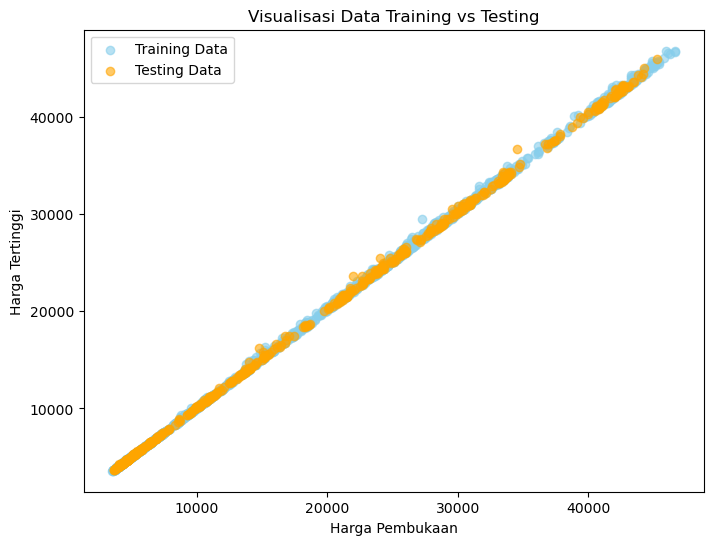

In [82]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

# --- Dataset Asli ---
# Pastikan df sudah dibaca dari CSV / Excel sebelumnya
# contoh: df = pd.read_csv("data.csv")

# Menentukan fitur dan label
#X = df[['Pembukaan', 'Tertinggi', 'Terendah','Vol.','Perubahan%','day','week','month','year']]
#y = df['Terakhir']  # Kolom 'Terakhir/price' menjadi label yang ingin diprediksi

# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("input data Training : ", X_train.shape)
print("output data Training : ", y_train.shape)
print("input data test : ", X_test.shape)
print("output data Test : ", y_test.shape)

# ---- VISUALISASI ----
plt.figure(figsize=(8,6))

# Untuk visualisasi ambil 2 fitur saja (misalnya Pembukaan vs Tertinggi)
plt.scatter(X_train["Pembukaan"], X_train["Tertinggi"], 
            c="skyblue", alpha=0.6, label="Training Data")
plt.scatter(X_test["Pembukaan"], X_test["Tertinggi"], 
            c="orange", alpha=0.6, label="Testing Data")

plt.xlabel("Harga Pembukaan")
plt.ylabel("Harga Tertinggi")
plt.title("Visualisasi Data Training vs Testing")
plt.legend()
plt.savefig('DATAtrainVStest.png')
plt.show()


In [83]:
df

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,day,week,month,year,Perubahan Terakhir
0,2024-12-27,43053.0,43460.0,43522.0,42635.0,1812.0,-1.73,27,52,12,2024,12.0
1,2024-12-26,43811.0,43908.0,44094.0,43663.0,820.0,-0.28,26,52,12,2024,448.0
2,2024-12-24,43933.0,43465.0,43960.0,43419.0,716.0,0.94,24,52,12,2024,-443.0
3,2024-12-23,43525.0,43674.0,43765.0,43283.0,1915.0,-0.31,23,52,12,2024,209.0
4,2024-12-20,43660.0,43311.0,44374.0,42863.0,6426.0,-0.10,20,51,12,2024,-363.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2762,2014-01-08,3576.0,3600.0,3614.0,3558.0,5998.0,-1.79,8,2,1,2014,12.0
2763,2014-01-07,3641.0,3633.0,3649.0,3621.0,3592.0,0.77,7,2,1,2014,33.0
2764,2014-01-06,3613.0,3685.0,3689.0,3611.0,4362.0,-2.11,6,2,1,2014,52.0
2765,2014-01-03,3691.0,3720.0,3722.0,3660.0,3113.0,-0.67,3,1,1,2014,35.0


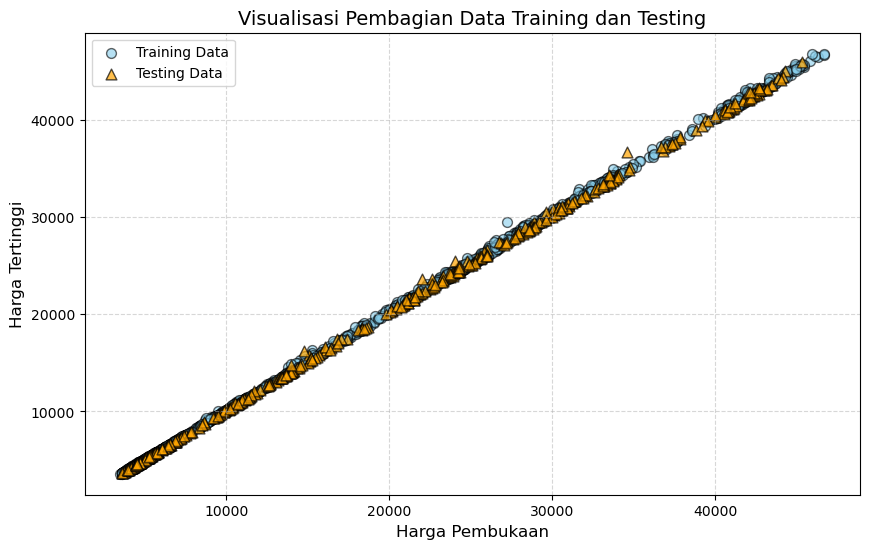

In [84]:
import matplotlib.pyplot as plt

# ---- VISUALISASI TRAINING vs TESTING ----
plt.figure(figsize=(10,6))

# Data training -> biru
plt.scatter(
    X_train["Pembukaan"], X_train["Tertinggi"],
    c="skyblue", alpha=0.6, edgecolor="k", s=50, label="Training Data"
)

# Data testing -> oranye
plt.scatter(
    X_test["Pembukaan"], X_test["Tertinggi"],
    c="orange", alpha=0.7, edgecolor="k", s=60, marker="^", label="Testing Data"
)

# Label sumbu dan judul
plt.xlabel("Harga Pembukaan", fontsize=12)
plt.ylabel("Harga Tertinggi", fontsize=12)
plt.title("Visualisasi Pembagian Data Training dan Testing", fontsize=14)

# Grid + legend
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


In [85]:
#Visualisasi Data hasil prediksi Vs Data Aktual

In [86]:
df

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,day,week,month,year,Perubahan Terakhir
0,2024-12-27,43053.0,43460.0,43522.0,42635.0,1812.0,-1.73,27,52,12,2024,12.0
1,2024-12-26,43811.0,43908.0,44094.0,43663.0,820.0,-0.28,26,52,12,2024,448.0
2,2024-12-24,43933.0,43465.0,43960.0,43419.0,716.0,0.94,24,52,12,2024,-443.0
3,2024-12-23,43525.0,43674.0,43765.0,43283.0,1915.0,-0.31,23,52,12,2024,209.0
4,2024-12-20,43660.0,43311.0,44374.0,42863.0,6426.0,-0.10,20,51,12,2024,-363.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2762,2014-01-08,3576.0,3600.0,3614.0,3558.0,5998.0,-1.79,8,2,1,2014,12.0
2763,2014-01-07,3641.0,3633.0,3649.0,3621.0,3592.0,0.77,7,2,1,2014,33.0
2764,2014-01-06,3613.0,3685.0,3689.0,3611.0,4362.0,-2.11,6,2,1,2014,52.0
2765,2014-01-03,3691.0,3720.0,3722.0,3660.0,3113.0,-0.67,3,1,1,2014,35.0


In [87]:
#model yang dibangun mampu memprediksi harga saham dengan akurat. Semakin dekat titik-titik dengan garis diagonal, 
#semakin baik performa model dalam memprediksi harga saham. Jika terdapat sebaran yang signifikan atau pola yang tidak teratur pada grafik, hal ini menunjukkan
#adanya ketidakakuratan dalam model yang perlu diperbaiki atau ditingkatkan.

In [88]:
#Garis horizontal pada nilai residual nol menunjukkan titik di mana prediksi benar-benar akurat, yaitu saat nilai prediksi sama dengan nilai aktual. Jika titik-titik pada grafik tersebar secara acak di sekitar garis horizontal, itu menunjukkan bahwa model memberikan prediksi yang akurat.
#Namun, jika terdapat pola atau kecenderungan tertentu pada titik-titik residual, itu menunjukkan adanya bias atau kesalahan sistematis dalam model.
#Dengan melihat grafik residual, kita dapat mengidentifikasi pola atau kecenderungan kesalahan dalam prediksi model. Jika terdapat pola tertentu, seperti residual yang cenderung meningkat atau menurun seiring dengan nilai prediksi, itu menunjukkan bahwa model mungkin memiliki bias
#atau kesalahan sistematis yang perlu diperbaiki. Jika titik-titik residual tersebar secara acak di sekitar nilai nol, itu menunjukkan bahwa model memberikan prediksi yang akurat secara keseluruhan.
#Grafik residual penting dalam mengevaluasi kualitas dan kecocokan model. Jika terdapat pola atau kecenderungan dalam residual, kita perlu melakukan penyesuaian atau perbaikan pada model untuk meningkatkan kualitas prediksinya.

In [89]:
#Kurva regresi dapat digunakan untuk memperkirakan nilai variabel dependen berdasarkan nilai variabel independen yang diberikan. Dengan melihat letak titik data terhadap kurva regresi, kita dapat memperoleh pemahaman tentang pola hubungan antara variabel input dan output.
#Misalnya, jika titik data berada di atas kurva regresi, itu menunjukkan nilai prediksi yang lebih tinggi dibandingkan dengan nilai aktual, dan sebaliknya.
#Kurva regresi memberikan gambaran visual tentang hubungan antara variabel input dan output dalam model regresi. Ini membantu kita memahami pola hubungan, mengevaluasi kualitas model, dan menggunakan kurva regresi untuk memperkirakan nilai variabel dependen berdasarkan
#variabel independen yang diberikan.

In [90]:
import joblib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# MODEL 1: Tanpa Scaling
model_no_scaling = LinearRegression()
model_no_scaling.fit(X_train, y_train)

# MODEL 2: Pipeline Scaling + LinearRegression
pipeline = make_pipeline(StandardScaler(), LinearRegression())
pipeline.fit(X_train, y_train)

# SIMPAN MODEL
joblib.dump(model_no_scaling, "model_no_scaling.joblib")
joblib.dump(pipeline, "model_pipeline.joblib")

print("Model berhasil disimpan!")


Model berhasil disimpan!


In [91]:
import joblib
import pandas as pd
loaded_model = joblib.load("model_no_scaling.joblib")
loaded_pipeline = joblib.load("model_pipeline.joblib")

# menggunakan model kembali:



In [92]:
import joblib
import pandas as pd
import numpy as np

print("="*60)
print("MENAMPILKAN MODEL YANG SUDAH DISIMPAN")
print("="*60)

# Load model dari file
model_no_scaling = joblib.load("model_no_scaling.joblib")
model_pipeline = joblib.load("model_pipeline.joblib")

print("\n=== MODEL TANPA SCALING ===")
print(f"Jenis Model: {type(model_no_scaling).__name__}")
print(f"Parameter model: {model_no_scaling.get_params()}")

# Cek apakah model memiliki atribut yang diperlukan
print(f"\nIntercept (bias): {model_no_scaling.intercept_}")
print(f"Koefisien shape: {model_no_scaling.coef_.shape}")

# Tampilkan semua atribut model
print("\nAtribut yang tersedia:")
for attr in dir(model_no_scaling):
    if not attr.startswith('_') and not callable(getattr(model_no_scaling, attr)):
        try:
            value = getattr(model_no_scaling, attr)
            if isinstance(value, (int, float, str, np.ndarray)):
                print(f"  {attr}: {value}")
            elif isinstance(value, np.ndarray) and value.size > 10:
                print(f"  {attr}: array dengan shape {value.shape}")
            else:
                print(f"  {attr}: {type(value).__name__}")
        except:
            pass

print("\n=== MODEL PIPELINE ===")
print(f"Jenis Model: {type(model_pipeline).__name__}")
print(f"Steps dalam pipeline: {list(model_pipeline.named_steps.keys())}")

# Tampilkan setiap step dalam pipeline
for step_name, step_obj in model_pipeline.named_steps.items():
    print(f"\nStep: {step_name}")
    print(f"  Jenis: {type(step_obj).__name__}")
    
    if hasattr(step_obj, 'get_params'):
        print(f"  Parameter: {step_obj.get_params()}")
    
    # Jika ini adalah StandardScaler
    if hasattr(step_obj, 'mean_'):
        print(f"  Mean: {step_obj.mean_}")
        print(f"  Scale: {step_obj.scale_}")
    
    # Jika ini adalah LinearRegression
    if hasattr(step_obj, 'coef_'):
        print(f"  Intercept: {step_obj.intercept_}")
        print(f"  Koefisien: {step_obj.coef_}")

# ===== PREDIKSI CONTOH =====
print("\n" + "="*60)
print(" PREDIKSI DENGAN MODEL")
print("="*60)

# Contoh prediksi dengan data dummy (sesuaikan dengan jumlah fitur model Anda)
# Cari tahu jumlah fitur yang dibutuhkan
n_features = len(model_no_scaling.coef_)
print(f"Model membutuhkan {n_features} fitur")

# Buat data dummy untuk prediksi
dummy_data = np.array([[1.0] * n_features])  # Data dengan semua nilai 1.0
print(f"\nData dummy untuk prediksi (shape: {dummy_data.shape}):")
print(dummy_data)

try:
    # Prediksi dengan model tanpa scaling
    pred1 = model_no_scaling.predict(dummy_data)
    print(f"\nPrediksi model tanpa scaling: {pred1[0]:.4f}")
    
    # Prediksi dengan model pipeline
    pred2 = model_pipeline.predict(dummy_data)
    print(f"Prediksi model dengan pipeline: {pred2[0]:.4f}")
    
except Exception as e:
    print(f"\nError dalam prediksi: {e}")
    print("Pastikan bentuk data dummy sesuai dengan yang diharapkan model")

MENAMPILKAN MODEL YANG SUDAH DISIMPAN

=== MODEL TANPA SCALING ===
Jenis Model: LinearRegression
Parameter model: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

Intercept (bias): 3.348206573187781
Koefisien shape: (5,)

Atribut yang tersedia:
  coef_: [-4.02297838e-01  6.72665179e-01  7.30547633e-01 -1.84752379e-03
  3.94330301e+01]
  copy_X: True
  feature_names_in_: ['Pembukaan' 'Tertinggi' 'Terendah' 'Vol.' 'Perubahan%']
  fit_intercept: True
  intercept_: 3.348206573187781
  n_features_in_: 5
  n_jobs: NoneType
  positive: False
  rank_: 5
  singular_: [1.01232129e+06 6.23446685e+04 6.07356683e+03 5.52477171e+03
 6.38843379e+01]

=== MODEL PIPELINE ===
Jenis Model: Pipeline
Steps dalam pipeline: ['standardscaler', 'linearregression']

Step: standardscaler
  Jenis: StandardScaler
  Parameter: {'copy': True, 'with_mean': True, 'with_std': True}
  Mean: [1.74012517e+04 1.75666480e+04 1.72283845e+04 2.91572526e+03
 1.05784004e-01]
  Scale: [1.24259196e+04 1

In [93]:
import joblib
import pandas as pd
import numpy as np

def display_model_info(model, model_name="Model"):
    """
    Menampilkan informasi detail dari sebuah model sklearn
    """
    print(f"\n{'='*60}")
    print(f"INFORMASI DETAIL: {model_name}")
    print('='*60)
    
    # Tampilkan tipe model
    print(f"Tipe Model: {type(model).__name__}")
    
    # Tampilkan parameter
    if hasattr(model, 'get_params'):
        params = model.get_params()
        print(f"\nParameter Model:")
        for key, value in params.items():
            print(f"  {key}: {value}")
    
    # Untuk LinearRegression
    if hasattr(model, 'coef_'):
        print(f"\nIntercept (bias): {model.intercept_}")
        print(f"Koefisien shape: {model.coef_.shape}")
        
        # Jika koefisien tidak terlalu banyak, tampilkan semuanya
        if len(model.coef_) <= 20:
            print("Koefisien detail:")
            for i, coef in enumerate(model.coef_):
                print(f"  Fitur {i+1}: {coef:.6f}")
        else:
            print(f"Koefisien (10 pertama): {model.coef_[:10]}")
            print(f"Koefisien (10 terakhir): {model.coef_[-10:]}")
    
    # Untuk Pipeline
    if hasattr(model, 'named_steps'):
        print(f"\nPipeline Steps:")
        for step_name, step_obj in model.named_steps.items():
            print(f"\n  Step: {step_name} ({type(step_obj).__name__})")
            
            # Tampilkan parameter untuk setiap step
            if hasattr(step_obj, 'get_params'):
                step_params = step_obj.get_params()
                if len(step_params) > 0:
                    print(f"    Parameter: {step_params}")
    
    # Tampilkan atribut lainnya
    print(f"\nAtribut penting lainnya:")
    important_attrs = ['rank_', 'singular_', 'n_features_in_', 'feature_names_in_']
    
    for attr in important_attrs:
        if hasattr(model, attr):
            value = getattr(model, attr)
            print(f"  {attr}: {value}")
    
    # Hitung dan tampilkan persamaan model (jika LinearRegression)
    if hasattr(model, 'coef_') and hasattr(model, 'intercept_'):
        print(f"\nPersamaan Model (untuk {len(model.coef_)} fitur):")
        equation = f"y = {model.intercept_:.4f}"
        for i, coef in enumerate(model.coef_):
            equation += f" + ({coef:.4f} * x{i+1})"
        print(f"  {equation}")

# Load model
model_no_scaling = joblib.load("model_no_scaling.joblib")
model_pipeline = joblib.load("model_pipeline.joblib")

# Tampilkan informasi
display_model_info(model_no_scaling, "Model Tanpa Scaling")
display_model_info(model_pipeline, "Model dengan Pipeline")

# ===== BUAT LAPORAN MODEL =====
print("\n" + "="*60)
print("LAPORAN MODEL LINEAR REGRESSION")
print("="*60)

# Cek performa model dengan data training (jika tersedia)
try:
    # Asumsi kita punya X_train dan y_train
    from sklearn.metrics import r2_score, mean_squared_error
    
    # Prediksi dengan model tanpa scaling
    y_pred_no_scaling = model_no_scaling.predict(X_train)
    r2_no_scaling = r2_score(y_train, y_pred_no_scaling)
    mse_no_scaling = mean_squared_error(y_train, y_pred_no_scaling)
    
    # Prediksi dengan model pipeline
    y_pred_pipeline = model_pipeline.predict(X_train)
    r2_pipeline = r2_score(y_train, y_pred_pipeline)
    mse_pipeline = mean_squared_error(y_train, y_pred_pipeline)
    
    print("\nPERFORMA MODEL PADA DATA TRAINING:")
    print(f"{'Metric':<20} {'Tanpa Scaling':<15} {'Dengan Pipeline':<15}")
    print(f"{'-'*50}")
    print(f"{'R-squared':<20} {r2_no_scaling:<15.4f} {r2_pipeline:<15.4f}")
    print(f"{'MSE':<20} {mse_no_scaling:<15.4f} {mse_pipeline:<15.4f}")
    print(f"{'RMSE':<20} {np.sqrt(mse_no_scaling):<15.4f} {np.sqrt(mse_pipeline):<15.4f}")
    
except NameError:
    print("\nCatatan: X_train dan y_train tidak tersedia untuk evaluasi performa")
    print("Model sudah disimpan dan siap digunakan untuk prediksi")

# ===== SIMPAN INFORMASI MODEL KE FILE =====
print("\n" + "="*60)
print("MENYIMPAN INFORMASI MODEL KE FILE TEKS")
print("="*60)

with open('model_info.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("INFORMASI MODEL LINEAR REGRESSION\n")
    f.write("="*60 + "\n\n")
    
    f.write("MODEL TANPA SCALING:\n")
    f.write(f"  Tipe: {type(model_no_scaling).__name__}\n")
    f.write(f"  Intercept: {model_no_scaling.intercept_}\n")
    f.write(f"  Koefisien: {model_no_scaling.coef_}\n\n")
    
    f.write("MODEL DENGAN PIPELINE:\n")
    f.write(f"  Tipe: {type(model_pipeline).__name__}\n")
    if 'linearregression' in model_pipeline.named_steps:
        lr = model_pipeline.named_steps['linearregression']
        f.write(f"  Intercept: {lr.intercept_}\n")
        f.write(f"  Koefisien: {lr.coef_}\n")
    
    f.write(f"\nModel disimpan pada: {pd.Timestamp.now()}")

print("Informasi model telah disimpan ke 'model_info.txt'")


INFORMASI DETAIL: Model Tanpa Scaling
Tipe Model: LinearRegression

Parameter Model:
  copy_X: True
  fit_intercept: True
  n_jobs: None
  positive: False

Intercept (bias): 3.348206573187781
Koefisien shape: (5,)
Koefisien detail:
  Fitur 1: -0.402298
  Fitur 2: 0.672665
  Fitur 3: 0.730548
  Fitur 4: -0.001848
  Fitur 5: 39.433030

Atribut penting lainnya:
  rank_: 5
  singular_: [1.01232129e+06 6.23446685e+04 6.07356683e+03 5.52477171e+03
 6.38843379e+01]
  n_features_in_: 5
  feature_names_in_: ['Pembukaan' 'Tertinggi' 'Terendah' 'Vol.' 'Perubahan%']

Persamaan Model (untuk 5 fitur):
  y = 3.3482 + (-0.4023 * x1) + (0.6727 * x2) + (0.7305 * x3) + (-0.0018 * x4) + (39.4330 * x5)

INFORMASI DETAIL: Model dengan Pipeline
Tipe Model: Pipeline

Parameter Model:
  memory: None
  steps: [('standardscaler', StandardScaler()), ('linearregression', LinearRegression())]
  verbose: False
  standardscaler: StandardScaler()
  linearregression: LinearRegression()
  standardscaler__copy: True
  s